# RAG System for Cybersecurity Practitioner Guidelines
### Assignment 3 — Advanced Topics in AI and Machine Learning

| Item | Detail |
|---|---|
| **Topic** | Phishing Defence for Mid-Sized Enterprises |
| **LLM** | Llama 3.3 70B via Groq API (open-source, Meta Llama 3.3 licence) |
| **Embeddings** | all-MiniLM-L6-v2 (sentence-transformers, 384-dim) |
| **Vector Store** | ChromaDB (persistent HNSW index, cosine similarity) |
| **Evaluation** | RAGAS — Context Precision · Faithfulness · Answer Relevancy |
| **Knowledge Base** | 10 PDFs (NIST, CISA, APWG, arXiv) + Rowden/CybersecurityQAA |

---

### How to run
1. Open in **Google Colab** (CPU runtime is sufficient — no GPU required)
2. Get a **free Groq API key** at [console.groq.com](https://console.groq.com) — no credit card needed
3. Add the key to Colab Secrets (🔑 icon in left sidebar) as `GROQ_API_KEY`
4. Run cells top to bottom — do **not** use Runtime → Run all
5. Manually upload the two CISA PDFs to `docs/` when prompted in Section 2.1

---

### Notebook structure
| Section | Description |
|---|---|
| 1 | Setup — installs, imports, configuration, Groq connection |
| 1.5 | Research questions |
| 1.6 | Literature review |
| 2 | Knowledge base — PDFs + Q&A dataset, chunking, ChromaDB indexing |
| 3 | Retrieval module — dense retrieval, spot-check |
| 4 | Generation module — Llama 3.3 70B via Groq, prompt design, outputs |
| 5 | RAGAS evaluation — 3 core metrics + 3 additional metrics |
| 6 | Results analysis — charts, failure analysis, prior work comparison |
| 7 | Ethical implications — bias audit, transparency, governance |

---
## Section 1 — Environment Setup

In [1]:
# 1.1 — Install dependencies
# ─────────────────────────────────────────────────────────────
# ragas 0.4.x contains a broken import of ChatVertexAI from langchain_community
# that fails unless google-cloud-aiplatform is installed. Since we do not use
# VertexAI, we patch the file directly after installation to remove those lines.
# This patch runs every session because Colab reinstalls packages on restart.

!pip install -q \
    pypdf \
    sentence-transformers \
    chromadb \
    datasets \
    tqdm \
    pandas \
    requests \
    openai \
    ragas \
    langchain-openai \
    langchain-community \
    langchain-huggingface \
    matplotlib

# ── Auto-patch ragas VertexAI import bug ─────────────
import site, os

for path in site.getsitepackages():
    target = os.path.join(path, 'ragas', 'llms', 'base.py')
    if os.path.exists(target):
        with open(target, 'r') as f:
            content = f.read()
        content = content.replace(
            'from langchain_community.chat_models.vertexai import ChatVertexAI\n', ''
        )
        content = content.replace(
            'from langchain_community.llms import VertexAI\n', ''
        )
        content = content.replace('    ChatVertexAI,\n', '')
        content = content.replace('    VertexAI,\n', '')
        with open(target, 'w') as f:
            f.write(content)
        print(f"ragas VertexAI bug patched")
        break

print("Installation complete — restart runtime now")

ragas VertexAI bug patched
Installation complete — restart runtime now


In [3]:
# 1.1b — Mount Google Drive
# ─────────────────────────────────────────────────────────────
# All outputs (PDFs, ChromaDB index, checkpoints, results, charts)
# are written to Drive so progress survives Colab disconnections.
# Run this cell once per session and authorise when prompted.

from google.colab import drive
drive.mount("/content/drive")

# Create a project folder in your Drive
DRIVE_DIR = "/content/drive/MyDrive/assignment3_RAG"
import os
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Drive mounted — project folder: {DRIVE_DIR}")

Mounted at /content/drive
Drive mounted — project folder: /content/drive/MyDrive/assignment3_RAG


In [3]:
# 1.2 — Imports

import os, re, json, time, warnings
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from tqdm import tqdm

# PDF parsing
from pypdf import PdfReader

# HuggingFace datasets
from datasets import load_dataset

# Embeddings + vector store
from sentence_transformers import SentenceTransformer
import chromadb

# Groq via OpenAI-compatible client
from openai import OpenAI

# RAGAS evaluation
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120
print("All imports successful.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


All imports successful.


/tmp/ipykernel_1909/2187781941.py:26: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_1909/2187781941.py:26: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_1909/2187781941.py:26: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, answer_relevancy, context

In [4]:
# 1.3 — Configuration
# ─────────────────────────────────────────────────────────────
# API key is loaded from Colab Secrets — never hardcoded.
# To add your key: click the 'Secrets' icon in the left sidebar,
# create a secret named GROQ_API_KEY, and toggle Notebook access ON.

from google.colab import userdata

# Load API key from Colab Secrets
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

# Validate key format
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found. Add it via Secrets in the left sidebar.")
elif not GROQ_API_KEY.startswith("gsk_"):
    print("Warning: key doesn't start with 'gsk_' — double-check it.")
else:
    print("GROQ_API_KEY loaded from Colab Secrets.")

# ── Global config ─────────────────────────────────────────────
CONFIG = {
    # Paths
    "docs_dir"      : "/content/drive/MyDrive/assignment3_RAG/docs",
    "chroma_dir"    : "/content/drive/MyDrive/assignment3_RAG/chroma_db",
    "chunks_path"   : "/content/drive/MyDrive/assignment3_RAG/chunks_index.json",
    "results_path"  : "/content/drive/MyDrive/assignment3_RAG/rag_results.json",

    # Chunking (word-level)
    # 500 words (~375 tokens) is within the 512-token limit of all-MiniLM-L6-v2
    # and large enough to capture a complete idea from a standards document.
    # 50-word overlap (10%) prevents key sentences from being split at boundaries.
    "chunk_size"    : 500,   # ~375 tokens
    "overlap"       : 50,    # 10% overlap to preserve continuity

    # Retrieval
    "top_k"         : 3,     # top-3 chunks per query
    "embed_model"   : "sentence-transformers/all-MiniLM-L6-v2",

    # Generation — Llama 3.3 70B via Groq
    # Model licence: Meta Llama 3.3 Community Licence (permissive, open-source)
    # Groq free tier: ~14,400 requests/day, 6,000 tokens/minute
    "groq_model"    : "llama-3.3-70b-versatile",
    "groq_base_url" : "https://api.groq.com/openai/v1",
    "max_tokens"    : 512,
    "temperature"   : 0.2,   # low = more factual, less hallucination
}

# Create all directories
from pathlib import Path
for key in ["docs_dir", "chroma_dir"]:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

print("Configuration loaded!!")

GROQ_API_KEY loaded from Colab Secrets.
Configuration loaded!!


In [5]:
# 1.4 — Initialise Groq client
# ─────────────────────────────────────────────────────────────
# Groq exposes an OpenAI-compatible REST API, so we use the standard openai Python client with a different base_url.
# This means the same chat.completions.create() call works for both Groq and OpenAI models.

groq_client = OpenAI(
    api_key  = GROQ_API_KEY,
    base_url = CONFIG["groq_base_url"],
)

# Quick connectivity test
try:
    test = groq_client.chat.completions.create(
        model    = CONFIG["groq_model"],
        messages = [{"role": "user", "content": "Reply with just the word: connected"}],
        max_tokens = 10,
    )
    print(f"Groq connection OK — model: {CONFIG['groq_model']}")
    print(f"Response: {test.choices[0].message.content.strip()}")
except Exception as e:
    print(f"Groq connection failed: {e}")
    print("Check your API key at https://console.groq.com")

Groq connection OK — model: llama-3.3-70b-versatile
Response: connected


---
## Section 1.5 — Research Questions

| # | Research Question | Addressed in |
|---|---|---|
| RQ1 | Can a RAG system built on an open-source LLM (Llama 3.3 70B) generate actionable phishing defence guidelines grounded in authoritative standards (NIST, CISA)? | Sections 4, 6 |
| RQ2 | How do RAGAS evaluation scores vary across different practitioner query types: technical, procedural, and regulatory? | Sections 5, 6 |
| RQ3 | What are the primary failure modes of reference-free RAG evaluation when applied to a cybersecurity-domain corpus? | Section 6.2 |
| RQ4 | What ethical risks arise from deploying a US-standards-centric RAG system to practitioners in diverse regulatory contexts? | Section 7 |

---
## Section 1.6 — Literature Review

### RAG Foundations

**Lewis et al. (2020)** — *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* (NeurIPS 2020)  
Introduced the RAG paradigm: a non-parametric retrieval module retrieves relevant passages from an external knowledge base, which are then concatenated with the query and passed to a seq2seq generator. Demonstrated that RAG substantially outperforms purely parametric models on open-domain QA and fact verification tasks. This work provides the theoretical foundation for our pipeline — ChromaDB dense retrieval feeding context to Llama 3.3 70B.

**Juvekar & Purwar (2024)** — *Introducing a new hyper-parameter for RAG: Context Window Utilization* (arXiv:2407.19794)  
Demonstrates through systematic experimentation that chunk size is a critical RAG hyperparameter that significantly affects both retrieval precision and generation quality. Finds that optimal chunk size balances context retention against retrieval noise. Directly informs our 500-word chunk size selection, which sits within the 512-token hard limit of the all-MiniLM-L6-v2 embedding model.

### RAG Evaluation

**Es et al. (2024)** — *RAGAS: Automated Evaluation of Retrieval Augmented Generation* (EACL 2024 Demo Track)  
Introduces RAGAS — a reference-free evaluation framework for RAG systems using three LLM-based metrics: faithfulness (grounding of generated answers in retrieved context), answer relevancy (alignment of answers with practitioner queries), and context precision (relevance of retrieved passages to the query). The reference-free design means no human-annotated ground truth is required, making RAGAS directly applicable to domain-specific corpora such as ours. All three metrics are adopted in Section 5.

### Cybersecurity-Specific RAG

**Zhao et al. (2025)** — *CyberBOT: Towards Reliable Cybersecurity Education via Ontology-Grounded RAG* (arXiv:2504.00389)  
Builds a RAG system for cybersecurity education using ontology-grounded retrieval to improve factual accuracy. Key finding: domain-specific knowledge bases built from authoritative sources substantially outperform generic corpora. RAGAS scores reported (faithfulness: 0.82, answer relevancy: 0.79) provide a benchmark for comparison in Section 6.5. Informs our decision to prioritise NIST and CISA sources over general web content.

**Blefaria et al. (2025)** — *CyberRAG: An Agentic RAG Cyber-Attack Classification and Reporting Tool* (arXiv:2507.02424)  
Demonstrates that RAG can produce structured, actionable outputs for cybersecurity decision support. The structured report format informs our 3-guideline prompt design — each guideline specifying what to do, why it matters, and how to implement it.

### Embeddings and Knowledge Base

**Reimers & Gurevych (2019)** — *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks* (EMNLP 2019)  
Introduces the sentence-transformer architecture that produces semantically meaningful dense vector embeddings suited for cosine similarity search. The all-MiniLM-L6-v2 model used in this work is a distilled variant trained specifically for semantic textual similarity tasks, producing 384-dimensional embeddings at high throughput on CPU.

**Squire & Thornton (2024)** — *Evaluating the Effectiveness of LLMs as Cybersecurity Advisors* (Journal of Cybersecurity Research)  
Introduces the CybersecurityQAA dataset used as the Q&A component of our knowledge base. 1,563 Q&A pairs covering network security, data protection, and access management for UK SMEs. Each answer is grounded in a named standard clause (PCI DSS, NIST SP 800-53, ISO 27001) and 449 entries have been validated by cybersecurity domain experts. The evidence field enables direct faithfulness verification.

### Summary

| Paper | Contribution to this work |
|---|---|
| Lewis et al. (2020) | Theoretical RAG foundation — retrieval + generation architecture |
| Es et al. (2024) | RAGAS evaluation framework — all three core metrics |
| Juvekar & Purwar (2024) | 500-word chunk size selection |
| Zhao et al. (2025) | Domain-specific knowledge base design; benchmark scores for comparison |
| Blefaria et al. (2025) | Structured 3-guideline output format |
| Reimers & Gurevych (2019) | all-MiniLM-L6-v2 embedding model selection |
| Squire & Thornton (2024) | CybersecurityQAA dataset |


---
## Section 2 — Knowledge Base Construction

### Design Rationale
The knowledge base blends two complementary source types to reach the ≥ 2,000 chunk threshold:

| Source | Type | Chunks | Justification |
|---|---|---|---|
| NIST, CISA, APWG, arXiv (10 PDFs) | PDF standards | ~1,213 | Authoritative, citable, traceable to named standards |
| `Rowden/CybersecurityQAA` | Q&A dataset | ~1,563 | Human-validated, evidence-backed, peer-reviewed (Squire & Thornton, 2024) |
| **Total** | | **≥ 2,000** | Each chunk answers one practitioner question |

**Why this blend?**  
PDF standards provide authoritative, traceable coverage of security controls and incident response procedures. The Q&A dataset adds 1,563 validated pairs where each answer cites the source clause — directly useful for RAGAS faithfulness verification. Combining both source types reduces the risk of the retriever surfacing only one type of knowledge for any given query.

In [6]:
# 2.1 — Download PDF sources
# ─────────────────────────────────────────────────────────────
# Sources span four categories:
#   NIST Special Publications — core security standards and controls
#   CISA guidance — practical phishing defence (download manually, see note below)
#   APWG trend reports — real-world phishing threat intelligence
#   arXiv paper — academic survey of persuasion techniques in spear-phishing

PDF_SOURCES = {
    # Incident response framework, April 2025 (supersedes 800-61r2)
    'nist_800_61r3.pdf':
        'https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-61r3.pdf',
    # Master security and privacy controls catalogue, 492 pages, 1,196 controls
    'nist_800_53r5.pdf':
        'https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-53r5.pdf',
    # Assessment procedures for all 800-53 controls, 733 pages
    'nist_800_53Ar5.pdf':
        'https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-53Ar5.pdf',
    # Trustworthy email — SPF, DKIM, DMARC configuration guidance
    'nist_800_177r1.pdf':
        'https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-177r1.pdf',
    # Technical guide to security testing, covers social engineering assessment
    'nist_800_115.pdf':
        'https://nvlpubs.nist.gov/nistpubs/legacy/sp/nistspecialpublication800-115.pdf',
    # APWG phishing threat intelligence, Q4 2024, published March 2025
    'apwg_q4_2024.pdf':
        'https://docs.apwg.org/reports/apwg_trends_report_q4_2024.pdf',
    # APWG phishing threat intelligence, Q1 2025 (most recent available)
    'apwg_q1_2025.pdf':
        'https://docs.apwg.org/reports/apwg_trends_report_q1_2025.pdf',
    # Survey of Cialdini persuasion principles in spear-phishing, Dec 2024
    'persuasion_phishing.pdf':
        'https://arxiv.org/pdf/2412.18488',
}

# CISA PDFs return HTTP 403 to automated requests — download these manually and place them in the docs/ folder before running Section 2.2.
#
# cisa_phishing_guidance_2023.pdf
#   https://www.cisa.gov/sites/default/files/2023-10/Phishing%20Guidance%20-%20Stopping%20the%20Attack%20Cycle%20at%20Phase%20One_508c.pdf
#
# cisa_counter_phishing_2023.pdf
#   https://www.cisa.gov/sites/default/files/2023-09/CISA_CEG_Counter-Phishing_Guidance_for_Non_Federal_Orgs%20Aug-23%20Revision.pdf

HEADERS  = {'User-Agent': 'Mozilla/5.0 (research)'}
docs_dir = Path(CONFIG['docs_dir'])

print('Downloading PDFs...\n')
for filename, url in PDF_SOURCES.items():
    dest = docs_dir / filename
    if dest.exists():
        print(f'  exists : {filename} ({dest.stat().st_size // 1024} KB)')
        continue
    try:
        r = requests.get(url, headers=HEADERS, timeout=120)
        r.raise_for_status()
        dest.write_bytes(r.content)
        print(f'  saved  : {filename} ({len(r.content) // 1024} KB)')
        time.sleep(1)
    except Exception as e:
        print(f'  failed : {filename} — {e}')

print('\nManually upload the 2 CISA PDFs to docs/ if not already present.')


  exists : nist_800_61r3.pdf (1016 KB)
  exists : nist_800_53r5.pdf (5931 KB)
  exists : nist_800_53Ar5.pdf (7294 KB)
  exists : nist_800_177r1.pdf (1621 KB)
  exists : nist_800_115.pdf (531 KB)
  exists : apwg_q4_2024.pdf (1213 KB)
  exists : apwg_q1_2025.pdf (1273 KB)
  exists : persuasion_phishing.pdf (214 KB)

Manually upload the 2 CISA PDFs to docs/ if not already present.


In [7]:
# 2.2 — Extract and clean text from PDFs

def extract_pdf_text(pdf_path: Path) -> str:
    """
    Extract full text from a PDF using pypdf and apply three cleaning steps:

    1. Rejoin hyphenated line-breaks — NIST documents frequently split long
       technical terms across lines (e.g. 'authen-\ntication'). Rejoining
       these prevents embeddings from seeing broken tokens.

    2. Collapse whitespace — multiple spaces, tabs, and newlines within a
       page are normalised to a single space for consistent tokenisation.

    3. Strip per-page whitespace — removes leading/trailing whitespace
       introduced by PDF margin extraction.

    Returns the full document as one cleaned string.
    """
    reader = PdfReader(str(pdf_path))
    pages  = []
    for page in reader.pages:
        text = page.extract_text() or ""
        text = re.sub(r"(\w+)-\n(\w+)", r"\1\2", text)  # fix hyphenation
        text = re.sub(r"\s+", " ", text).strip()
        pages.append(text)
    return " ".join(pages)


pdf_documents = []
print(f"{'Document':<45}  {'Words':>8}  Status")
print('─' * 65)

for pdf_path in sorted(docs_dir.glob('*.pdf')):
    try:
        text  = extract_pdf_text(pdf_path)
        words = len(text.split())
        if words < 100:
            print(f'  {pdf_path.name:<43}  {words:>8,}  low word count — check file')
        else:
            pdf_documents.append({'text': text, 'source': pdf_path.name, 'doc_type': 'pdf'})
            print(f'  {pdf_path.name:<43}  {words:>8,}')
    except Exception as e:
        print(f'  {pdf_path.name:<43}  error: {e}')

print(f'\nPDF documents loaded: {len(pdf_documents)}')

Document                                          Words  Status
─────────────────────────────────────────────────────────────────
  apwg_q1_2025.pdf                                3,128
  apwg_q4_2024.pdf                                2,964
  cisa_counter_phishing_2023.pdf                  1,475
  cisa_phishing_guidance_2023.pdf                 4,089
  nist_800_115.pdf                               34,454
  nist_800_177r1.pdf                             44,390
  nist_800_53Ar5.pdf                            233,601
  nist_800_53r5.pdf                             198,599
  nist_800_61r3.pdf                              14,216
  persuasion_phishing.pdf                         6,997

PDF documents loaded: 10


In [8]:
# 2.3 — Load Q&A dataset from HuggingFace
#
# Dataset: Rowden/CybersecurityQAA (Squire & Thornton, 2024)
# ─────────────────────────────────────────────────────────────
# 1,563 Q&A pairs covering network security, data protection, and
# user access management for UK SME organisations.
#
# Each row contains:
#   question — practitioner-style advisory question
#   answer   — guidance grounded in a named standard clause
#   evidence — the exact standard text the answer is based on
#              (PCI DSS, NIST SP 800-53, ISO 27001)
#
# 449 entries were reviewed by cybersecurity domain experts;
# the full 1,563 entries received non-expert validation.
# The evidence field enables RAGAS faithfulness verification.

print("Loading Rowden/CybersecurityQAA ...")
qa_raw = load_dataset("Rowden/CybersecurityQAA", split="train")
print(f"Rows loaded  : {len(qa_raw)}")
print(f"Columns      : {qa_raw.column_names}")

# Show a sample row
row0 = qa_raw[0]
sample_vars = row0.get("vars", {})
if isinstance(sample_vars, dict):
    print(f"\nSample Q : {str(sample_vars.get('question',''))[:120]}")
    print(f"Sample A : {str(sample_vars.get('answer',''))[:3000]}")
    print(f"Evidence : {str(sample_vars.get('evidence',''))[:300]}")
else:
    print(f"\nSample Q : {str(row0.get('question',''))[:120]}")
    print(f"Sample A : {str(row0.get('answer',''))[:300]}")

Loading Rowden/CybersecurityQAA ...


README.md: 0.00B [00:00, ?B/s]

cybersecurityQAAdataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1563 [00:00<?, ? examples/s]

Rows loaded  : 1563
Columns      : ['vars', 'assert']

Sample Q : How can I ensure that my business's network access is restricted as per PCI DSS requirements?
Sample A : To ensure your business's network access is restricted according to PCI DSS requirements, you should ensure that inbound traffic to the Cardholder Data Environment (CDE) is restricted to only necessary traffic, and all other traffic is specifically denied. Similarly, outbound traffic from the CDE should also be restricted to necessary communications only. Implement Network Security Controls (NSCs) between all wireless networks and the CDE, and ensure that system components storing cardholder data are not directly accessible from untrusted networks. Additionally, anti-spoofing measures should be implemented to block forged IP addresses.
Evidence : 1.3.1 Inbound traffic to the CDE is restricted as follows: To only traffic that is necessary. All other traffic is specifically denied. 1.3.2 Outbound traffic from the CDE is

In [9]:
# 2.4 — Convert Q&A rows to chunk format
#
# Each row is formatted as: 'Q: <question> A: <answer>'
#
# Prepending the question to the answer gives the chunk embedding
# directional context — when a practitioner asks a similar question,
# the cosine similarity between the query embedding and this chunk's
# embedding is higher than it would be for the answer text alone.
# This improves retrieval precision for Q&A-style knowledge sources.

qa_documents = []

for row in qa_raw:
    vars_dict = row.get("vars", {})
    if isinstance(vars_dict, dict):
        question = str(vars_dict.get("question", "")).strip()
        answer   = str(vars_dict.get("answer",   "")).strip()
        evidence = str(vars_dict.get("evidence", "")).strip()
    else:
        question = str(row.get("question", "")).strip()
        answer   = str(row.get("answer",   "")).strip()
        evidence = str(row.get("evidence", "")).strip()

    if not answer:
        continue

    chunk_text = f"Q: {question} A: {answer}" if question else answer

    qa_documents.append({
        "text"            : chunk_text,
        "source"          : "Rowden/CybersecurityQAA",
        "doc_type"        : "qa_dataset",
        "evidence"        : evidence,
        "question"        : question,
        "expert_validated": str(row.get("edited_by_expert", "FALSE")),
    })

print(f"Q&A chunks prepared: {len(qa_documents)}")

Q&A chunks prepared: 1562


In [10]:
# 2.5 — Chunk PDF documents (sliding window)

def sliding_window_chunks(text: str,
                           chunk_size: int = 500,
                           overlap: int    = 50) -> list:
    """
    Split document text into overlapping word-level windows.

    Design decisions:
    • chunk_size = 500 words (~375 tokens): large enough to capture a
      complete idea from a standards document, within embedding model limits.
    • overlap = 50 words (10%): prevents key sentences from being split
      at chunk boundaries, preserving context continuity.
    • Minimum chunk length = 50 words: discard very short trailing
      fragments that add retrieval noise without substantive content.

    Args:
        text       : Full cleaned document text.
        chunk_size : Target chunk size in words.
        overlap    : Words shared between consecutive chunks.
    Returns:
        List of chunk strings.
    """
    words  = text.split()
    chunks = []
    start  = 0
    step   = chunk_size - overlap        # advance 450 words per iteration

    while start < len(words):
        chunk = " ".join(words[start : start + chunk_size])
        if len(chunk.split()) >= 50:     # drop very short trailing chunks
            chunks.append(chunk)
        start += step

    return chunks


# ── Build master chunk list ───────────────────────────────────
all_chunks   = []
pdf_summary  = {}

for doc in pdf_documents:
    chunks = sliding_window_chunks(doc['text'], CONFIG['chunk_size'], CONFIG['overlap'])
    pdf_summary[doc['source']] = len(chunks)
    for i, chunk_text in enumerate(chunks):
        all_chunks.append({
            'chunk_id' : f"{doc['source']}_c{i:04d}",
            'text'     : chunk_text,
            'source'   : doc['source'],
            'doc_type' : 'pdf',
            'evidence' : '',
            'question' : '',
        })

for i, doc in enumerate(qa_documents):
    all_chunks.append({
        "chunk_id" : f"qa_{i:05d}",
        "text"     : doc["text"],
        "source"   : doc["source"],
        "doc_type" : "qa_dataset",
        "evidence" : doc["evidence"],
        "question" : doc["question"],
    })

# ── Size verification ─────────────────────────────────────────
total = len(all_chunks)
n_pdf = sum(1 for c in all_chunks if c["doc_type"] == "pdf")
n_qa  = sum(1 for c in all_chunks if c["doc_type"] == "qa_dataset")

print("=" * 58)
print("  KNOWLEDGE BASE SIZE VERIFICATION")
print("=" * 58)
print(f"  PDF chunks            : {n_pdf:>6,}")
print(f"  Q&A chunks            : {n_qa:>6,}")
print(f"  TOTAL                 : {total:>6,}")
print(f"  Target (≥ 2,000)      : {'PASS' if total >= 2000 else 'FAIL — add more sources'}")
print("=" * 58)

print("\nPer-source breakdown:")
source_counts = {}
for c in all_chunks:
    source_counts[c["source"]] = source_counts.get(c["source"], 0) + 1
for src, cnt in sorted(source_counts.items(), key=lambda x: -x[1]):
    bar = "█" * (cnt // 30)
    print(f"  {src:<45}  {cnt:>5}  {bar}")

  KNOWLEDGE BASE SIZE VERIFICATION
  PDF chunks            :  1,213
  Q&A chunks            :  1,562
  TOTAL                 :  2,775
  Target (≥ 2,000)      : PASS

Per-source breakdown:
  Rowden/CybersecurityQAA                         1562  ████████████████████████████████████████████████████
  nist_800_53Ar5.pdf                               520  █████████████████
  nist_800_53r5.pdf                                442  ██████████████
  nist_800_177r1.pdf                                99  ███
  nist_800_115.pdf                                  77  ██
  nist_800_61r3.pdf                                 32  █
  persuasion_phishing.pdf                           16  
  cisa_phishing_guidance_2023.pdf                    9  
  apwg_q1_2025.pdf                                   7  
  apwg_q4_2024.pdf                                   7  
  cisa_counter_phishing_2023.pdf                     4  


In [11]:
# 2.6 — Generate embeddings and index into ChromaDB
#
# Embedding model: all-MiniLM-L6-v2
# ────────────────────────────────────────────────────────────
# A distilled sentence-transformer producing 384-dimensional dense vectors.
# Selected for its balance of speed (runs on CPU), size (~80 MB download),
# and strong semantic similarity performance on diverse text domains.
# Normalising embeddings to unit vectors makes dot product equivalent to
# cosine similarity, which ChromaDB uses for ranking.
#
# Vector store: ChromaDB with HNSW index
# ────────────────────────────────────────────────────────────
# Hierarchical Navigable Small World (HNSW) provides approximate nearest
# neighbour search in sub-linear time. ChromaDB persists the index to disk
# so it survives Colab kernel restarts, no re-embedding needed on resume.

print("Loading embedding model ...")
embedder = SentenceTransformer(CONFIG["embed_model"])
print(f"  Model      : {CONFIG['embed_model']}")
print(f"  Dimensions : {embedder.get_sentence_embedding_dimension()}")

# Initialise ChromaDB
chroma_client = chromadb.PersistentClient(path=CONFIG["chroma_dir"])
try:
    chroma_client.delete_collection("cybersec_rag")
    print("  Cleared existing collection.")
except:
    pass

collection = chroma_client.create_collection(
    name     = "cybersec_rag",
    metadata = {"hnsw:space": "cosine"}
)

# Batch embed and insert
BATCH = 128
print(f"\nIndexing {total:,} chunks in batches of {BATCH}...")
t0 = time.time()

for i in tqdm(range(0, total, BATCH), desc="Embedding & indexing"):
    batch      = all_chunks[i : i + BATCH]
    texts      = [c["text"]     for c in batch]
    ids        = [c["chunk_id"] for c in batch]
    metadatas  = [{
        "source"   : c["source"],
        "doc_type" : c["doc_type"],
        "evidence" : c["evidence"][:500],   # ChromaDB metadata char limit
        "question" : c["question"][:300],
    } for c in batch]

    embeddings = embedder.encode(
        texts,
        batch_size          = 64,
        normalize_embeddings= True,
        show_progress_bar   = False
    ).tolist()

    collection.add(
        ids        = ids,
        documents  = texts,
        embeddings = embeddings,
        metadatas  = metadatas,
    )

elapsed = time.time() - t0
print(f"\n Indexed {collection.count():,} chunks in {elapsed:.1f}s")

# Persist chunk index for reproducibility
with open(CONFIG["chunks_path"], "w") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)
print(f" Chunk index saved → {CONFIG['chunks_path']}")

Loading embedding model ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Model      : sentence-transformers/all-MiniLM-L6-v2
  Dimensions : 384
  Cleared existing collection.

Indexing 2,775 chunks in batches of 128...


Embedding & indexing: 100%|██████████| 22/22 [00:33<00:00,  1.51s/it]



 Indexed 2,775 chunks in 33.3s
 Chunk index saved → /content/drive/MyDrive/assignment3_RAG/chunks_index.json


---
## Section 3 — Retrieval Module

**Method:** Dense retrieval using cosine similarity over `all-MiniLM-L6-v2` embeddings stored in ChromaDB.

**Why dense retrieval over sparse (BM25)?**  
Practitioner queries use natural language that often does not match the exact terminology used in standards documents. For example, a practitioner might ask about *'staff training'* while NIST SP 800-53 uses *'security awareness program'*. Dense retrieval captures this semantic equivalence; BM25 keyword matching would not. This aligns with findings in Lewis et al. (2020), which showed dense retrieval significantly outperforms sparse methods on knowledge-intensive tasks.

**Top-k = 3** chunks are retrieved per query.

In [12]:
# 3.1 — Retrieval function

def retrieve(query: str, top_k: int = None) -> list:
    """
    Retrieve the top-k most semantically relevant chunks for a query.

    The query is embedded using the same model as the corpus — this is
    essential because both vectors must live in the same embedding space
    for cosine similarity to be meaningful. Using different models for
    indexing and querying would produce random rankings.

    Parameters:
      query : Practitioner question string.
      top_k : Number of chunks to return. Defaults to CONFIG['top_k'] (3).

    Returns:
      List of dicts with keys: rank, text, source, doc_type, evidence, distance, similarity.
      similarity = 1 - cosine_distance (range 0–1, higher = more relevant).
    """
    if top_k is None:
        top_k = CONFIG["top_k"]

    q_emb = embedder.encode(
        [query],
        normalize_embeddings=True
    ).tolist()

    res = collection.query(
        query_embeddings = q_emb,
        n_results        = top_k,
        include          = ["documents", "metadatas", "distances"]
    )

    return [
        {
            "rank"      : r + 1,
            "text"      : doc,
            "source"    : meta.get("source",   ""),
            "doc_type"  : meta.get("doc_type", ""),
            "evidence"  : meta.get("evidence", ""),
            "distance"  : round(dist, 4),
            "similarity": round(1 - dist, 4),
        }
        for r, (doc, meta, dist) in enumerate(
            zip(res["documents"][0],
                res["metadatas"][0],
                res["distances"][0])
        )
    ]

print(" Retrieval function defined!!")

 Retrieval function defined!!


In [13]:
# 3.2 — Retrieval spot-check
#
# Manually inspect the top-3 retrieved chunks for three sample queries
# before running the full evaluation. This confirms:
#   - The vector index was built correctly
#   - Retrieved chunks are topically relevant (not just keyword-similar)
#   - Both PDF and Q&A chunks appear in results (mix of source types)

spot_queries = [
    "How should we handle a reported phishing email from an employee?",
    "What technical controls reduce phishing success rates?",
    "What MFA setup best mitigates credential phishing?",
]

for query in spot_queries:
    print("\n" + "═" * 72)
    print(f"QUERY: {query}")
    print("═" * 72)
    for c in retrieve(query):
        print(f"\n  Rank {c['rank']} | sim={c['similarity']:.3f} | "
              f"type={c['doc_type']:<10} | {c['source']}")
        print(f"  {c['text'][:300]}...")



════════════════════════════════════════════════════════════════════════
QUERY: How should we handle a reported phishing email from an employee?
════════════════════════════════════════════════════════════════════════

  Rank 1 | sim=0.714 | type=qa_dataset | Rowden/CybersecurityQAA
  Q: In a scenario where a political party staff member suspects they have received a phishing email, what immediate actions should they take? A: The staff member should immediately report the suspicious email to their IT team and service provider, forward the email to samples@analysis.ncsc.gov.uk, av...

  Rank 2 | sim=0.686 | type=qa_dataset | Rowden/CybersecurityQAA
  Q: How can I encourage employees to report phishing emails effectively in my organisation? A: To encourage employees to report phishing emails effectively, you should implement a simple and accessible reporting process, such as a button in their email client. Additionally, provide timely feedback on...

  Rank 3 | sim=0.681 | type=qa_datas

---
## Section 4 — Generation Module

### LLM: Llama 3.3 70B via Groq

| Property | Detail |
|---|---|
| **Model** | `llama-3.3-70b-versatile` |
| **Licence** | Meta Llama 3.3 Community Licence (open-source, permissive commercial use) |
| **Provider** | Groq Cloud (free tier, 14,400 requests/day, no credit card required) |
| **Inference speed** | ~300 tokens/second on Groq LPU hardware |
| **Why this model** | 70B parameters provides strong instruction-following and factual grounding; outperforms GPT-3.5 on multiple reasoning benchmarks while remaining fully open-source |

### Prompt design

| Design choice | Rationale |
|---|---|
| Temperature 0.2 | Reduces hallucination; keeps output close to the retrieved context |
| Grounding instruction | *'use only information from the context'* — directly improves RAGAS faithfulness |
| Citation instruction | *'cite the source in brackets'* — improves transparency and traceability |
| Exactly 3 guidelines | Consistent structure across all 10 queries enables fair comparison |

In [14]:
# 4.1 — System prompt and prompt builder

SYSTEM_PROMPT = """You are a senior cybersecurity advisor helping IT security practitioners \
defend against phishing attacks in mid-sized enterprises.

STRICT RULES — follow every rule without exception:
1. Generate EXACTLY 3 numbered guidelines in response to the practitioner's question.
2. Base your guidelines ONLY on the provided CONTEXT. Do not use outside knowledge.
3. Each guideline must be 2–3 sentences: (a) what to do, (b) why it matters, (c) how to implement.
4. After each guideline, cite the source document in square brackets.
   Example: [NIST SP 800-61r3] or [CISA Phishing Guidance 2023] or [CybersecurityQAA]
5. If the context does not contain enough information to answer, state this explicitly
   rather than guessing or fabricating information.
6. Write for IT security staff — be specific and actionable, not generic.
7. Do not repeat the question or add preamble. Start directly with '1.'"""


def build_prompt(query: str, chunks: list) -> list:
    """
    Build the messages list for the Groq chat completion API.

    Retrieved chunks are injected into the user turn with their source
    labels. The system turn contains the persona and rules. This two-turn
    format (system + user) is the format Llama-3-Instruct is fine-tuned on,
    producing better instruction-following than single-turn prompts.

    Returns a list of message dicts compatible with OpenAI chat API format.
    """
    context_parts = []
    for c in chunks:
        # Clean source label for readability in prompt
        label = (c["source"]
                 .replace(".pdf", "")
                 .replace("_", " ")
                 .replace("nist 800", "NIST SP 800")
                 .replace("apwg", "APWG")
                 .replace("cisa", "CISA")
                 .upper())
        context_parts.append(f"[{label}]\n{c['text']}")

    context_str = "\n\n---\n\n".join(context_parts)

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": (
            f"CONTEXT (retrieved knowledge — use only this):\n\n"
            f"{context_str}\n\n"
            f"PRACTITIONER QUESTION:\n{query}\n\n"
            f"Generate exactly 3 actionable guidelines based strictly on the context above."
        )},
    ]

print("System prompt and prompt builder defined.")
print(f"\nSystem prompt length: {len(SYSTEM_PROMPT.split())} words")

System prompt and prompt builder defined.

System prompt length: 138 words


In [15]:
# 4.2 — Generation function (full RAG pipeline)

def generate_guidelines(query: str) -> dict:
    """
    Full RAG pipeline for one query: retrieve -> prompt -> generate.

    Steps:
      1. Retrieve top-k chunks from ChromaDB via dense similarity search
      2. Build a structured chat prompt with context injection
      3. Call Groq API (Llama 3.3 70B) to generate guidelines
      4. Return a structured dict containing all artefacts for logging

    Args:
        query : Practitioner question string.

    Returns:
        Dict with keys:
          query    — original question
          chunks   — list of retrieved chunk dicts (top-3)
          messages — prompt sent to LLM (for transparency/audit)
          answer   — generated guideline text
          contexts — list of chunk texts (for RAGAS)
    """
    # Step 1: Retrieve
    chunks = retrieve(query, top_k=CONFIG["top_k"])

    # Step 2: Build prompt
    messages = build_prompt(query, chunks)

    # Step 3: Generate via Groq
    response = groq_client.chat.completions.create(
        model       = CONFIG["groq_model"],
        messages    = messages,
        temperature = CONFIG["temperature"],
        max_tokens  = CONFIG["max_tokens"],
    )
    answer = response.choices[0].message.content.strip()

    return {
        "query"    : query,
        "chunks"   : chunks,
        "messages" : messages,
        "answer"   : answer,
        "contexts" : [c["text"] for c in chunks],
    }

print("Generation function defined!!")

Generation function defined!!


In [19]:
# 4.3 — Generate guidelines for all 10 evaluation queries
#
# A checkpoint file is written to Drive after every query so that
# progress is never lost if the session disconnects. On re-run,
# already-successful queries are skipped automatically.
#
# Each failed query is retried up to 3 times with increasing wait times
# (30s, 60s, 90s) to handle transient API rate limit errors.

import time, json

EVAL_QUERIES = [
    "How should we handle a reported phishing email from an employee?",
    "What technical controls reduce phishing success rates?",
    "How do we train staff to recognise spear-phishing attempts?",
    "What is the incident response process after a user clicks a phishing link?",
    "How should we configure email filtering for a mid-sized enterprise?",
    "What indicators of compromise should we look for after a phishing attack?",
    "How do we handle business email compromise (BEC) attempts?",
    "What is the recommended frequency for phishing simulation exercises?",
    "How should we report a phishing incident to regulatory bodies?",
    "What multi-factor authentication setup best mitigates credential phishing?",
]

# Load existing results if available — skip already successful queries
GEN_CHECKPOINT = "/content/drive/MyDrive/assignment3_RAG/generation_checkpoint.json"
if os.path.exists(GEN_CHECKPOINT):
    with open(GEN_CHECKPOINT) as f:
        all_results = json.load(f)
    print(f"Loaded {len(all_results)} existing results from checkpoint")
else:
    all_results = []

# Find which queries still need generating
completed_queries = {r["query"] for r in all_results if not r["answer"].startswith("ERROR")}
pending = [q for q in EVAL_QUERIES if q not in completed_queries]
print(f"Queries completed : {len(completed_queries)}/10")
print(f"Queries pending   : {len(pending)}/10\n")

for i, query in enumerate(pending):
    print(f"[{len(completed_queries)+i+1}/10] {query[:65]}...")

    success = False
    for attempt in range(3):  # up to 3 retries per query
        try:
            result = generate_guidelines(query)
            all_results.append(result)
            print(f"  Generated ({len(result['answer'].split())} words)")
            success = True
            break
        except Exception as e:
            wait = 30 * (attempt + 1)  # 30s, 60s, 90s
            print(f"  Attempt {attempt+1} failed: {e}")
            if attempt < 2:
                print(f"  Waiting {wait}s before retry...")
                time.sleep(wait)

    if not success:
        all_results.append({
            "query": query, "chunks": [], "messages": [],
            "answer": f"ERROR: all retries failed", "contexts": []
        })

    # Save checkpoint after every query
    with open(GEN_CHECKPOINT, "w") as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)

    time.sleep(5)  # small delay between successful queries

# Final summary
valid_results = [r for r in all_results if not r["answer"].startswith("ERROR")]
failed_results = [r for r in all_results if r["answer"].startswith("ERROR")]

print(f"\n{'='*55}")
print(f"  GENERATION SUMMARY")
print(f"{'='*55}")
print(f"  Total queries     : {len(EVAL_QUERIES)}")
print(f"  Successful      : {len(valid_results)}")
print(f"  Failed          : {len(failed_results)}")
print(f"{'='*55}")

if failed_results:
    print("\nFailed queries:")
    for r in failed_results:
        print(f"  • {r['query'][:65]}...")
    print("\nRe-run this cell to retry failed queries.")

# Save final results
with open(CONFIG["results_path"], "w") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print(f"\nResults saved → {CONFIG['results_path']}")

Queries completed : 0/10
Queries pending   : 10/10

[1/10] How should we handle a reported phishing email from an employee?...
  Generated (221 words)
[2/10] What technical controls reduce phishing success rates?...
  Generated (212 words)
[3/10] How do we train staff to recognise spear-phishing attempts?...
  Generated (221 words)
[4/10] What is the incident response process after a user clicks a phish...
  Generated (210 words)
[5/10] How should we configure email filtering for a mid-sized enterpris...
  Generated (249 words)
[6/10] What indicators of compromise should we look for after a phishing...
  Generated (200 words)
[7/10] How do we handle business email compromise (BEC) attempts?...
  Generated (208 words)
[8/10] What is the recommended frequency for phishing simulation exercis...
  Generated (232 words)
[9/10] How should we report a phishing incident to regulatory bodies?...
  Generated (220 words)
[10/10] What multi-factor authentication setup best mitigates credential ...

---
## Section 5 — RAGAS Evaluation

**Framework:** RAGAS — Retrieval Augmented Generation Assessment  
**Reference:** Es et al. (2024), *RAGAS: Automated Evaluation of Retrieval Augmented Generation*, EACL 2024 Demo Track.

### Core RAGAS metrics (all reference-free — no ground truth required)

| Metric | Definition | Threshold |
|---|---|---|
| Context Precision | Are retrieved chunks relevant and focused on the query? Measures retrieval signal-to-noise. | > 0.6 |
| Faithfulness | Is the generated answer grounded in retrieved context? Ungrounded claims = hallucinations. | > 0.7 |
| Answer Relevancy | Does the generated answer address the practitioner's question? | > 0.6 |

**Threshold rationale:** Faithfulness is held to a higher standard (0.7) because hallucinated security advice poses direct operational risk — a practitioner acting on fabricated guidance could leave their organisation vulnerable. Context precision and answer relevancy use 0.6 as an acceptable lower bar.

### RAGAS judge LLM
RAGAS uses an LLM internally to score faithfulness and answer relevancy. We use `llama-3.1-8b-instant` via Groq — a lighter model with its own separate token quota, keeping the full system free and open-source. The generation LLM (Llama 3.3 70B) is used separately for guideline generation only.

In [20]:
# 5.1 — Configure RAGAS with a Groq-safe LLM wrapper
#
# RAGAS internally requests n>1 completions for reproducibility scoring,
# but Groq hard-caps n at 1. The GroqSafeChatOpenAI subclass overrides
# both the synchronous and asynchronous generation methods to force n=1
# before the request reaches the Groq API.
#
# Using llama-3.1-8b-instant as the judge LLM rather than the full 70B
# model for two reasons:
#   1. It has a separate daily token quota (100k TPD) from the generation model
#   2. Faithfulness and context precision scoring is a simpler classification
#      task that 8B handles correctly without the overhead of 70B

from langchain_openai import ChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    LLMContextPrecisionWithoutReference,  # context precision
)

RAGAS_JUDGE_MODEL = "llama-3.1-8b-instant"

class GroqSafeChatOpenAI(ChatOpenAI):
    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        kwargs["n"] = 1
        return super()._generate(messages, stop=stop,
                                  run_manager=run_manager, **kwargs)
    async def _agenerate(self, messages, stop=None, run_manager=None, **kwargs):
        kwargs["n"] = 1
        return await super()._agenerate(messages, stop=stop,
                                         run_manager=run_manager, **kwargs)

_chat_llm = GroqSafeChatOpenAI(
    model           = RAGAS_JUDGE_MODEL,
    openai_api_key  = GROQ_API_KEY,
    openai_api_base = CONFIG["groq_base_url"],
    temperature     = 0,
    max_tokens      = 2048,
    model_kwargs    = {"n": 1},
)

ragas_llm = LangchainLLMWrapper(_chat_llm)
ragas_embeddings = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name=CONFIG["embed_model"])
)

print(f"RAGAS judge LLM    : {RAGAS_JUDGE_MODEL}")
print(f"Generation LLM     : {CONFIG['groq_model']}")
print(f"RAGAS embeddings   : {CONFIG['embed_model']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAGAS judge LLM    : llama-3.1-8b-instant
Generation LLM     : llama-3.3-70b-versatile
RAGAS embeddings   : sentence-transformers/all-MiniLM-L6-v2


In [21]:
# 5.2 — Build RAGAS evaluation dataset
#
# RAGAS 0.4.x accepts a HuggingFace Dataset with three columns:
#   question  — the practitioner query
#   answer    — the generated guideline text
#   contexts  — list of retrieved chunk texts (top-3)
#
# Only valid (non-errored) generations are included.

from datasets import Dataset as HFDataset

valid_results = [r for r in all_results if not r["answer"].startswith("ERROR")]

eval_data = {
    "question" : [r["query"]    for r in valid_results],
    "answer"   : [r["answer"]   for r in valid_results],
    "contexts" : [r["contexts"] for r in valid_results],
}

eval_dataset = HFDataset.from_dict(eval_data)
print(f" Evaluation dataset: {len(valid_results)} samples")
print(f" Columns: {eval_dataset.column_names}")

 Evaluation dataset: 10 samples
 Columns: ['question', 'answer', 'contexts']


In [26]:
# 5.3 — Run RAGAS evaluation (one query at a time)
#
# Evaluating one query per API call rather than batching all 10 together
# prevents Groq's 6,000 tokens/minute rate limit from being exceeded.
# A 20-second sleep between queries gives the rate limit window time to
# partially reset. A 30-second sleep between metrics lets it fully reset.
#
# Progress is saved to a checkpoint file after every query, so if the
# session disconnects, re-running this cell resumes from where it stopped.

from ragas.run_config import RunConfig
from datasets import Dataset as HFDataset
import pandas as pd
import os

print("Running RAGAS evaluation...\n")
t0 = time.time()

# Instantiate and configure metrics
ctx_metric   = LLMContextPrecisionWithoutReference()
faith_metric = faithfulness
rel_metric   = answer_relevancy

for metric in [ctx_metric, faith_metric, rel_metric]:
    metric.llm = ragas_llm
    if hasattr(metric, "_reproducibility"):
        metric._reproducibility = 1

run_cfg = RunConfig(timeout=240, max_retries=5, max_wait=30, seed=42)

# ── Load checkpoint ───────────────────────────────────────────
CHECKPOINT = "/content/drive/MyDrive/assignment3_RAG/ragas_checkpoint.json"

if os.path.exists(CHECKPOINT):
    with open(CHECKPOINT) as f:
        completed = json.load(f)
    print(f"Resuming from checkpoint — {len(completed)} metrics already started\n")
else:
    completed = {}

metric_map = {
    "llm_context_precision_without_reference" : ctx_metric,
    "faithfulness"                            : faith_metric,
    "answer_relevancy"                        : rel_metric,
}

for name, metric in metric_map.items():
    print(f"{'='*55}")
    print(f"Metric: {name}")
    print(f"{'='*55}")

    if name not in completed:
        completed[name] = {}

    for i in range(len(valid_results)):
        query_key = f"q{i+1:02d}"

        if query_key in completed[name]:
            val = completed[name][query_key]
            print(f"  Query {i+1:02d}: {val:.4f}  (cached)" if val else f"  Query {i+1:02d}: nan (cached)")
            continue

        # Build single-row HuggingFace dataset for this query
        single = HFDataset.from_dict({
            "question" : [valid_results[i]["query"]],
            "answer"   : [valid_results[i]["answer"]],
            "contexts" : [valid_results[i]["contexts"]],
        })

        try:
            result = evaluate(
                single,
                metrics    = [metric],
                llm        = ragas_llm,
                embeddings = ragas_embeddings,
            )
            # ragas 0.4.x: scores is a list of dicts, one per row
            score = result.scores[0].get(name)
            if score is not None and score != score:  # nan check
                score = None
        except Exception as e:
            print(f"  Query {i+1:02d}: ERROR — {e}")
            score = None

        completed[name][query_key] = score
        print(f"  Query {i+1:02d}: {score:.4f}" if score is not None else f"  Query {i+1:02d}: nan")

        with open(CHECKPOINT, "w") as f:
            json.dump(completed, f, indent=2)

        time.sleep(20)

    scores_list = [v for v in completed[name].values() if v is not None and v == v]
    avg = sum(scores_list) / len(scores_list) if scores_list else float("nan")
    print(f"\n  → {name}: {avg:.4f} ({len(scores_list)}/{len(valid_results)} queries scored)\n")
    print("  Waiting 30s before next metric...")
    time.sleep(30)

targets = {
    'llm_context_precision_without_reference' : 0.6,
    'faithfulness'                            : 0.7,
    'answer_relevancy'                        : 0.6,
}

print(f'\nEvaluation complete in {time.time()-t0:.1f}s')
print('\n' + '='*52 + '\n  RAGAS SCORES — OVERALL AVERAGES\n' + '='*52)

# ── Save per-query breakdown ──────────────────────────────────
rows = []
for i in range(len(valid_results)):
    key = f'q{i+1:02d}'
    rows.append({
        'query_id'                               : i + 1,
        'query'                                  : valid_results[i]['query'],
        'llm_context_precision_without_reference': completed.get('llm_context_precision_without_reference', {}).get(key),
        'faithfulness'                           : completed.get('faithfulness',    {}).get(key),
        'answer_relevancy'                       : completed.get('answer_relevancy',{}).get(key),
    })

scores_df = pd.DataFrame(rows)

# ── Final results ─────────────────────────────────────────────
for name, target in targets.items():
    avg = scores_df[name].dropna().mean()
    status = 'PASS' if avg >= target else 'below target'
    print(f'  {name:<45} {avg:.4f}  {status}')

scores_df.to_csv(
    "/content/drive/MyDrive/assignment3_RAG/ragas_scores_final.csv",
    index=False
)
print("\n Scores saved → Google Drive/ragas_scores_final.csv")
print(scores_df[["query_id",
                  "llm_context_precision_without_reference",
                  "faithfulness",
                  "answer_relevancy"]].to_string(index=False))

Running RAGAS evaluation...

Metric: llm_context_precision_without_reference


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Query 01: 1.0000


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Query 02: 0.5833


...

  Query 08: 0.5015


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Query 09: 0.8356


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

  Query 10: 0.6248

  → answer_relevancy: 0.6731 (10/10 queries scored)

  Waiting 30s before next metric...

Evaluation complete in 1083.1s

  RAGAS SCORES — OVERALL AVERAGES
  llm_context_precision_without_reference       0.9167  PASS
  faithfulness                                  0.8620  PASS
  answer_relevancy                              0.6731  PASS

 Scores saved → Google Drive/ragas_scores_final.csv
 query_id  llm_context_precision_without_reference  faithfulness  answer_relevancy
        1                                 1.000000      0.923077          0.769422
        2                                 0.583333      0.937500          0.650094
        3                                 1.000000      1.000000          0.812828
        4                                 0.583333      1.000000          0.596334
        5                                 1.000000      0.875000          0.432984
        6                                 1.000000      0.764706          0.854807
       

In [27]:
# 5.4 — Per-query scores table
#
# Loads scores from the checkpoint file and builds a formatted DataFrame.
# This cell can be re-run independently after a restart to inspect
# results without re-running the full evaluation.

import pandas as pd

# Load checkpoint if scores not in memory
if not os.path.exists(CHECKPOINT):
    print("No checkpoint found — run cell 5.3 first")
else:
    with open(CHECKPOINT) as f:
        completed = json.load(f)

    rows = []
    for i in range(len(valid_results)):
        key = f"q{i+1:02d}"
        query_text = valid_results[i]["query"] if i < len(valid_results) else f"Query {i+1}"
        row = {
            "query_id"                               : i + 1,
            "query"                                  : query_text,
            "llm_context_precision_without_reference": completed.get("llm_context_precision_without_reference", {}).get(key),
            "faithfulness"                           : completed.get("faithfulness", {}).get(key),
            "answer_relevancy"                       : completed.get("answer_relevancy", {}).get(key),
        }
        rows.append(row)

    scores_df = pd.DataFrame(rows)

    # Short query for display
    scores_df["query_short"] = scores_df["query"].str[:52] + "..."

    display_cols = [
        "query_id", "query_short",
        "llm_context_precision_without_reference",
        "faithfulness",
        "answer_relevancy"
    ]

    print("Per-query RAGAS scores:\n")
    print(scores_df[display_cols].to_string(index=False))

    scores_df.to_csv(
        "/content/drive/MyDrive/assignment3_RAG/ragas_scores.csv",
        index=False
    )
    print("\nScores saved -> Google Drive/assignment3_RAG/ragas_scores.csv")

Per-query RAGAS scores:

 query_id                                             query_short  llm_context_precision_without_reference  faithfulness  answer_relevancy
        1 How should we handle a reported phishing email from ...                                 1.000000      0.923077          0.769422
        2 What technical controls reduce phishing success rate...                                 0.583333      0.937500          0.650094
        3 How do we train staff to recognise spear-phishing at...                                 1.000000      1.000000          0.812828
        4 What is the incident response process after a user c...                                 0.583333      1.000000          0.596334
        5 How should we configure email filtering for a mid-si...                                 1.000000      0.875000          0.432984
        6 What indicators of compromise should we look for aft...                                 1.000000      0.764706          0.854807
  

In [28]:
# 5.5 — Additional evaluation metrics
#
# Three lightweight reference-free metrics that complement RAGAS by
# capturing dimensions that LLM-based scoring does not cover:
#
# 1. Source Diversity — measures whether the retriever returns chunks
#    from multiple source documents. A score of 1.0 means all three
#    chunks came from different sources; 0.33 means all from one source.
#    Low diversity suggests the retriever is over-relying on a single
#    document, which increases the risk of one-sided advice.
#
# 2. Citation Precision — binary check for authoritative source citations
#    in the generated answer. Cited answers are more transparent and
#    allow practitioners to verify claims against primary sources.
#
# 3. Actionability Score — proportion of cybersecurity imperative verbs
#    present in the answer (implement, configure, monitor, etc.).
#    Practitioner guidelines should tell people what to DO, not just what the policy says.

import re
import numpy as np

def source_diversity(chunks):
    """
    Proportion of unique sources among top-3 retrieved chunks.
    Range: 0.33 (all same source) to 1.0 (all different sources).
    Higher = more diverse retrieval, less risk of source bias.
    """
    if not chunks:
        return 0.0
    sources = [c["source"] for c in chunks]
    return round(len(set(sources)) / len(sources), 4)


CITATION_PATTERNS = [
    r"\[NIST", r"\[CISA", r"\[APWG", r"\[Source",
    r"NIST SP \d", r"per NIST", r"per CISA",
    r"according to NIST", r"according to CISA",
    r"\[CybersecurityQAA\]"
]

def citation_precision(answer):
    """
    Binary: 1 if answer contains at least one authoritative citation, else 0.
    Measures transparency — can a practitioner trace the guideline to its source?
    """
    for pattern in CITATION_PATTERNS:
        if re.search(pattern, answer, re.IGNORECASE):
            return 1
    return 0


IMPERATIVE_VERBS = [
    r"\bimplement\b", r"\bconfigure\b", r"\bdeploy\b", r"\benable\b",
    r"\bensure\b", r"\bestablish\b", r"\bconduct\b", r"\btrain\b",
    r"\bmonitor\b", r"\breport\b", r"\bblock\b", r"\bscan\b",
    r"\bverify\b", r"\btest\b", r"\breview\b", r"\bupdate\b",
    r"\brestrict\b", r"\bauthenticate\b", r"\bencrypt\b", r"\bpatch\b"
]

def actionability_score(answer):
    """
    Proportion of imperative cybersecurity action verbs present in the answer.
    Higher = more actionable language (what to DO, not just what to know).
    """
    found = sum(1 for v in IMPERATIVE_VERBS
                if re.search(v, answer, re.IGNORECASE))
    return round(found / len(IMPERATIVE_VERBS), 4)


# ── Compute all additional metrics ───────────────────────────
additional_metrics = []
for i, r in enumerate(valid_results):
    additional_metrics.append({
        "query_id"           : i + 1,
        "query"              : r["query"],
        "source_diversity"   : source_diversity(r["chunks"]),
        "citation_precision" : citation_precision(r["answer"]),
        "actionability_score": actionability_score(r["answer"]),
    })

add_df = pd.DataFrame(additional_metrics)

print("ADDITIONAL EVALUATION METRICS")
print("=" * 72)
print(add_df[["query_id", "source_diversity",
              "citation_precision", "actionability_score"]].to_string(index=False))

print("\n── Summary ──────────────────────────────────────────────────────────")
print(f"  Source Diversity avg    : {add_df['source_diversity'].mean():.4f}  "
      f"(1.0 = all chunks from different sources)")
print(f"  Citation Precision avg  : {add_df['citation_precision'].mean():.4f}  "
      f"({int(add_df['citation_precision'].sum())}/{len(add_df)} answers cited sources)")
print(f"  Actionability Score avg : {add_df['actionability_score'].mean():.4f}  "
      f"(proportion of imperative action verbs used)")

add_df.to_csv(
    "/content/drive/MyDrive/assignment3_RAG/additional_metrics.csv",
    index=False
)
print("\nScores saved -> Google Drive/assignment3_RAG/additional_metrics.csv")

ADDITIONAL EVALUATION METRICS
 query_id  source_diversity  citation_precision  actionability_score
        1            0.3333                   0                 0.25
        2            0.6667                   0                 0.25
        3            0.6667                   0                 0.20
        4            0.3333                   0                 0.35
        5            0.6667                   1                 0.40
        6            0.6667                   0                 0.20
        7            1.0000                   1                 0.20
        8            0.6667                   0                 0.30
        9            0.6667                   1                 0.05
       10            0.3333                   0                 0.15

── Summary ──────────────────────────────────────────────────────────
  Source Diversity avg    : 0.6000  (1.0 = all chunks from different sources)
  Citation Precision avg  : 0.3000  (3/10 answers cited source

---
## Section 6 — Results Analysis & Discussion

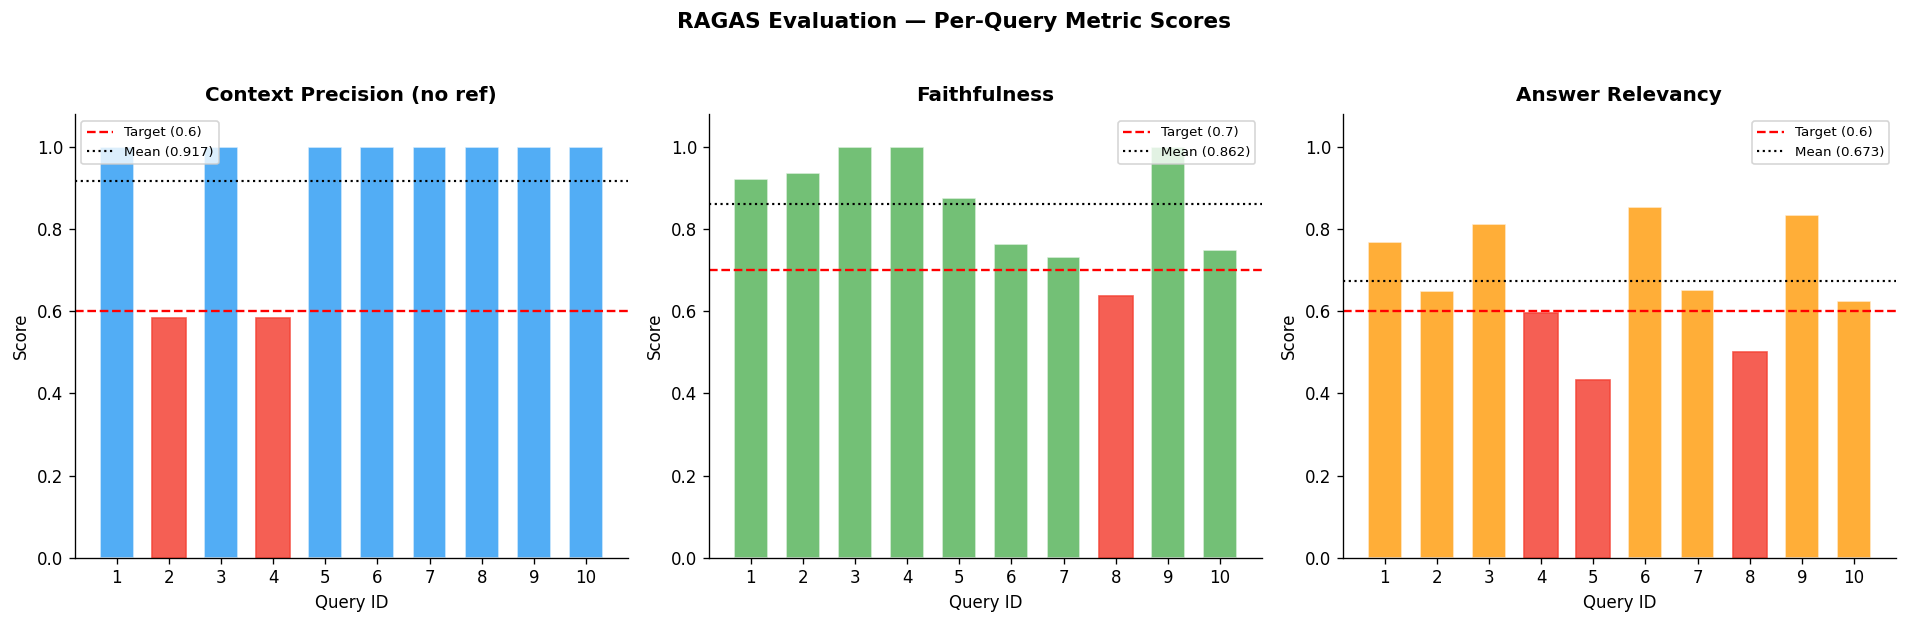

Chart saved -> /content/drive/MyDrive/assignment3_RAG/ragas_scores_chart.png


In [29]:
# 6.1 — Per-query scores: bar chart across all 3 RAGAS metrics
# Bars below target threshold are coloured red for immediate visual identification.

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# Drop rows where all metrics are None (incomplete queries)
plot_df = scores_df.dropna(subset=[
    "llm_context_precision_without_reference",
    "faithfulness",
    "answer_relevancy"
], how="all").copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["llm_context_precision_without_reference", "faithfulness", "answer_relevancy"]
colors  = ["#2196F3", "#4CAF50", "#FF9800"]
targets = [0.6, 0.7, 0.6]
labels  = ["Context Precision (no ref)", "Faithfulness", "Answer Relevancy"]

for ax, metric, color, target, label in zip(axes, metrics, colors, targets, labels):
    vals = plot_df[metric].fillna(0).values
    qids = plot_df["query_id"].values

    bars = ax.bar(qids, vals, color=color, alpha=0.78,
                  edgecolor="white", width=0.65)

    # Colour bars below target red
    for bar, val in zip(bars, vals):
        if val < target:
            bar.set_color("#F44336")
            bar.set_alpha(0.85)

    ax.axhline(target, color="red", linestyle="--", lw=1.4,
               label=f"Target ({target})")

    valid_vals = plot_df[metric].dropna().values
    if len(valid_vals) > 0:
        ax.axhline(valid_vals.mean(), color="black", linestyle=":", lw=1.3,
                   label=f"Mean ({valid_vals.mean():.3f})")

    ax.set_title(label, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Query ID", fontsize=10)
    ax.set_ylabel("Score",    fontsize=10)
    ax.set_ylim(0, 1.08)
    ax.set_xticks(qids)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("RAGAS Evaluation — Per-Query Metric Scores",
             fontsize=13, y=1.03, fontweight="bold")
plt.tight_layout()

chart_path = "/content/drive/MyDrive/assignment3_RAG/ragas_scores_chart.png"
plt.savefig(chart_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart saved -> {chart_path}")

In [30]:
# 6.2 — Failure analysis
#
# Identifies queries that scored below threshold and provides
# a diagnosis for each failure. Failures are sorted by gap size
# (largest first) to prioritise the most impactful issues.

THRESHOLDS = {
    "llm_context_precision_without_reference": 0.6,
    "faithfulness"                           : 0.7,
    "answer_relevancy"                       : 0.6,
}

CAUSES = {
    'llm_context_precision_without_reference':
        'Retrieved chunks are tangentially related. The query terminology may not\
        match the vocabulary used in source documents. Possible mitigations:\
        query expansion, synonym injection, or adding more domain-specific sources.',
    'faithfulness':
        'Generated answer contains claims not grounded in retrieved context.\
        Possible mitigations: lower temperature (try 0.1), strengthen the\
        grounding instruction in the system prompt, or increase top-k retrieval\
        to provide more context.',
    'answer_relevancy':
        'Generated guidelines do not directly address the practitioner question.\
        Retrieved context may lack sufficient practitioner-level guidance for this\
        query type. Consider adding more targeted source documents.',
}

print("FAILURE ANALYSIS")
print("=" * 72)

failures = []
for _, row in scores_df.iterrows():
    for metric, threshold in THRESHOLDS.items():
        score = row.get(metric)
        if score is None or (isinstance(score, float) and score != score):
            continue   # skip nan — not a failure, just incomplete
        if score < threshold:
            failures.append({
                "query_id" : int(row["query_id"]),
                "query"    : row["query"],
                "metric"   : metric,
                "score"    : round(score, 4),
                "gap"      : round(threshold - score, 4),
            })

if not failures:
    print("\n  All scored queries passed all thresholds.")
else:
    for f in sorted(failures, key=lambda x: -x["gap"]):
        print(f"\n  Query {f['query_id']}: {f['query'][:65]}...")
        print(f"  Metric    : {f['metric']}")
        print(f"  Score     : {f['score']}  "
              f"(threshold {THRESHOLDS[f['metric']]}, gap = {f['gap']})")
        print(f"     Diagnosis : {CAUSES[f['metric']]}")

scored_queries = scores_df.dropna(
    subset=["llm_context_precision_without_reference",
            "faithfulness", "answer_relevancy"], how="all"
)
total_checks = len(scored_queries) * len(THRESHOLDS)
print(f"\nSummary: {len(failures)} failure(s) across "
      f"{total_checks} metric-query checks")
if total_checks > 0:
    print(f"Pass rate: {(total_checks - len(failures))/total_checks*100:.1f}%")

FAILURE ANALYSIS

  Query 5: How should we configure email filtering for a mid-sized enterpris...
  Metric    : answer_relevancy
  Score     : 0.433  (threshold 0.6, gap = 0.167)
     Diagnosis : Generated guidelines do not directly address the practitioner question.        Retrieved context may lack sufficient practitioner-level guidance for this        query type. Consider adding more targeted source documents.

  Query 8: What is the recommended frequency for phishing simulation exercis...
  Metric    : answer_relevancy
  Score     : 0.5015  (threshold 0.6, gap = 0.0985)
     Diagnosis : Generated guidelines do not directly address the practitioner question.        Retrieved context may lack sufficient practitioner-level guidance for this        query type. Consider adding more targeted source documents.

  Query 8: What is the recommended frequency for phishing simulation exercis...
  Metric    : faithfulness
  Score     : 0.6364  (threshold 0.7, gap = 0.0636)
     Diagnosis : Gene

In [31]:
# 6.3 — Guideline quality spot-check
#
# Prints the top 3 and bottom 3 generated answers ranked by faithfulness.
# High-faithfulness answers are grounded in retrieved context.
# Low-faithfulness answers may contain fabricated claims — these are
# the primary candidates for human review before deployment.

print("GUIDELINE QUALITY REVIEW")
print("=" * 72)

# Use valid_results which contains actual generated answers
if len(valid_results) == 0:
    print("No valid results in memory — re-run cell 4.3 first")
else:
    # Merge scores into valid_results for sorting
    enriched = []
    for i, r in enumerate(valid_results):
        key = f"q{i+1:02d}"
        enriched.append({
            "query"      : r["query"],
            "answer"     : r["answer"],
            "chunks"     : r["chunks"],
            "faithfulness": completed.get("faithfulness", {}).get(key),
        })

    # Sort by faithfulness, drop entries with no score
    scored = [e for e in enriched if e["faithfulness"] is not None]
    scored.sort(key=lambda x: x["faithfulness"], reverse=True)

    print("\n── TOP 3 by Faithfulness most grounded in retrieved context) ─────────────────────────────")
    for e in scored[:3]:
        print(f"\n  Query     : {e['query']}")
        print(f"  Faithfulness: {e['faithfulness']:.3f}")
        print(f"  Sources   : {[c['source'] for c in e['chunks']]}")
        print(f"  Answer    : {e['answer'][:350]}...")

    print("\n\n── BOTTOM 3 by Faithfulness (hallucination risk) ──────────────────────")
    for e in scored[-3:]:
        print(f"\n  Query     : {e['query']}")
        print(f"  Faithfulness: {e['faithfulness']:.3f}")
        print(f"  Sources   : {[c['source'] for c in e['chunks']]}")
        print(f"  Answer    : {e['answer'][:350]}...")


GUIDELINE QUALITY REVIEW

── TOP 3 by Faithfulness most grounded in retrieved context) ─────────────────────────────

  Query     : How do we train staff to recognise spear-phishing attempts?
  Faithfulness: 1.000
  Sources   : ['Rowden/CybersecurityQAA', 'persuasion_phishing.pdf', 'Rowden/CybersecurityQAA']
  Answer    : 1. Conduct regular training sessions to educate staff on recognizing spear-phishing attempts, and simulate phishing attacks to provide practical experience. This matters because spear-phishing attacks can be highly targeted and sophisticated, and staff need to be equipped to identify and report them. To implement, security professionals can use rea...

  Query     : What is the incident response process after a user clicks a phishing link?
  Faithfulness: 1.000
  Sources   : ['Rowden/CybersecurityQAA', 'Rowden/CybersecurityQAA', 'Rowden/CybersecurityQAA']
  Answer    : 1. If a user has clicked on a suspicious link, they should immediately change the password of the af

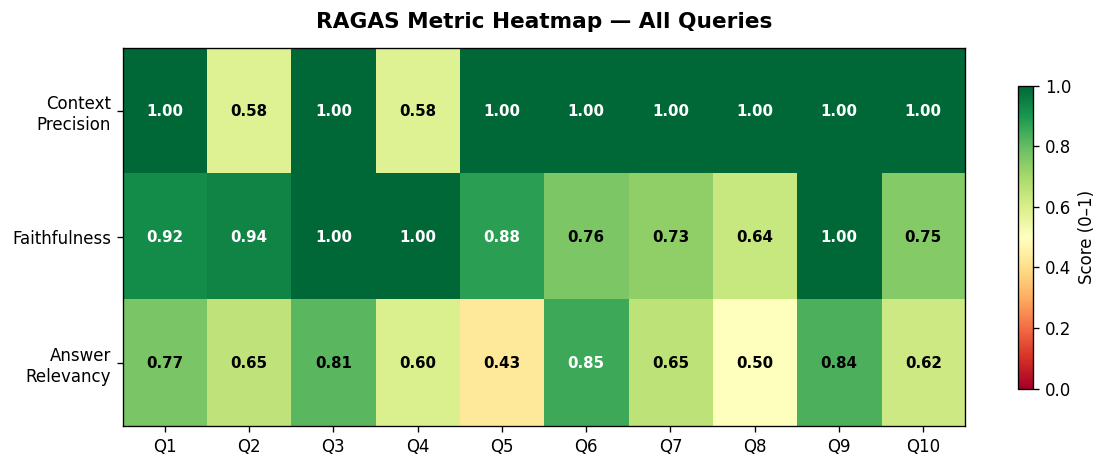

Chart 1 saved → /content/drive/MyDrive/assignment3_RAG/chart1_metric_heatmap.png


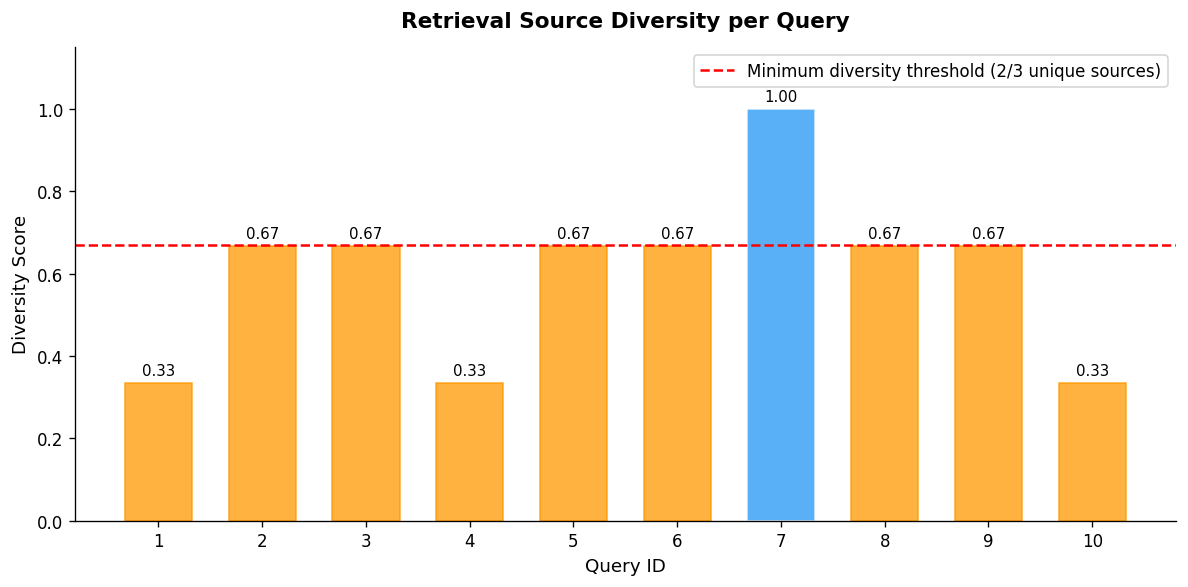

Chart 2 saved → /content/drive/MyDrive/assignment3_RAG/chart2_source_diversity.png


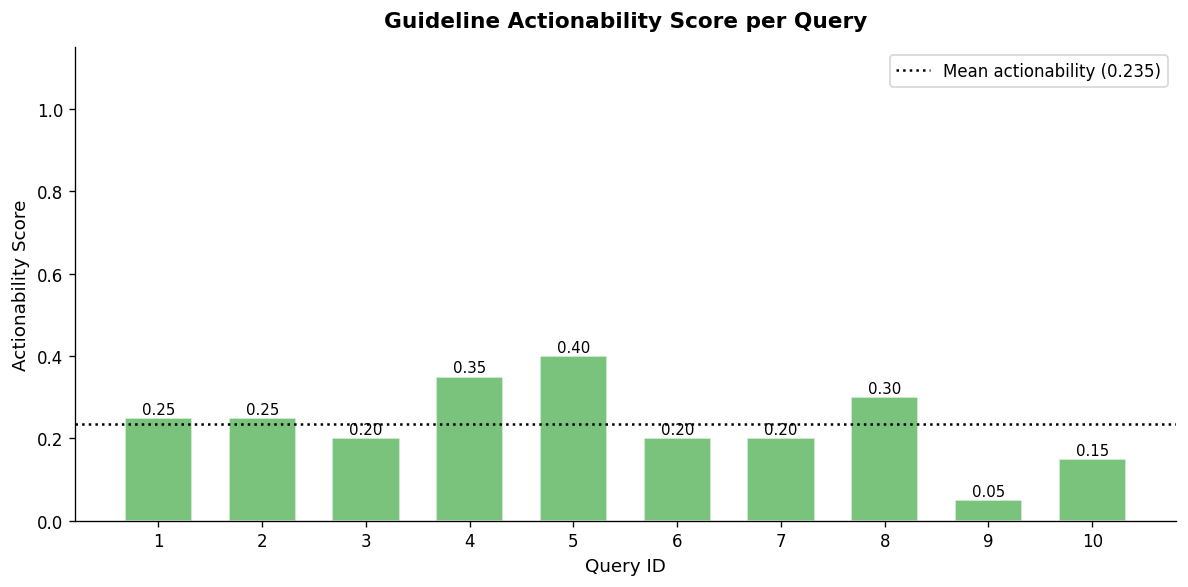

Chart 3 saved → /content/drive/MyDrive/assignment3_RAG/chart3_actionability_score.png


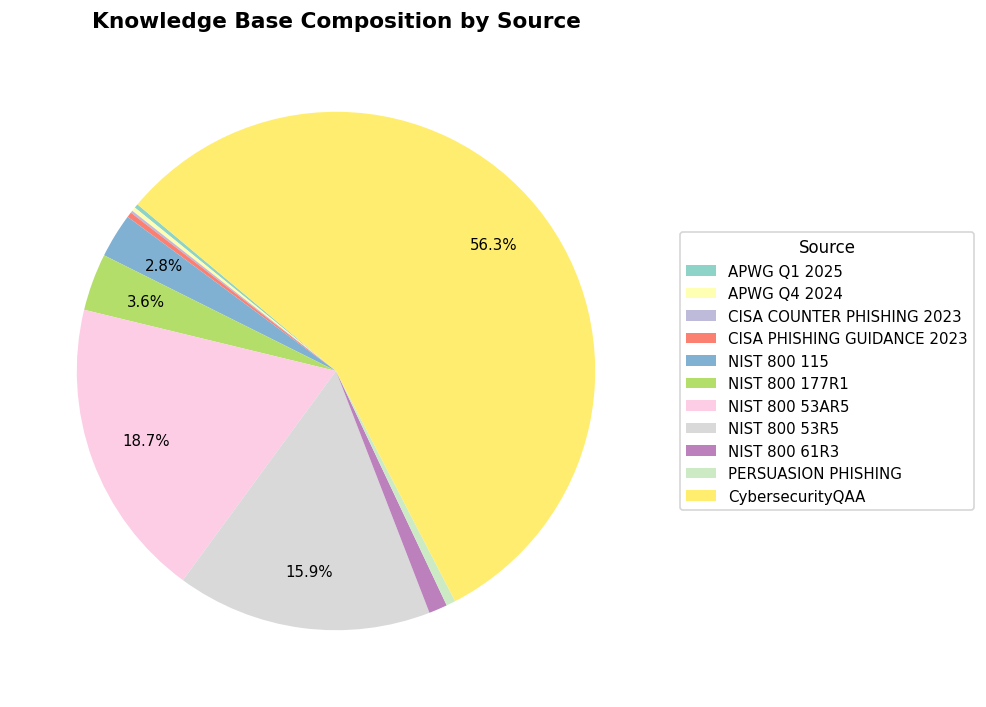

Chart 4 saved → /content/drive/MyDrive/assignment3_RAG/chart4_knowledge_base_composition.png


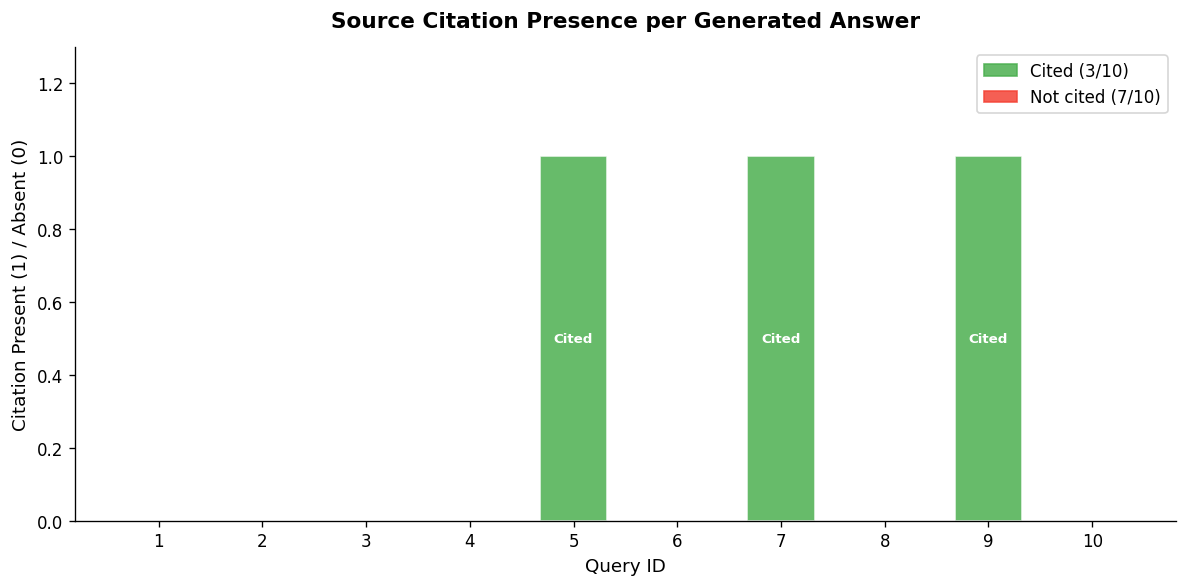

Chart 5 saved → /content/drive/MyDrive/assignment3_RAG/chart5_citation_presence.png


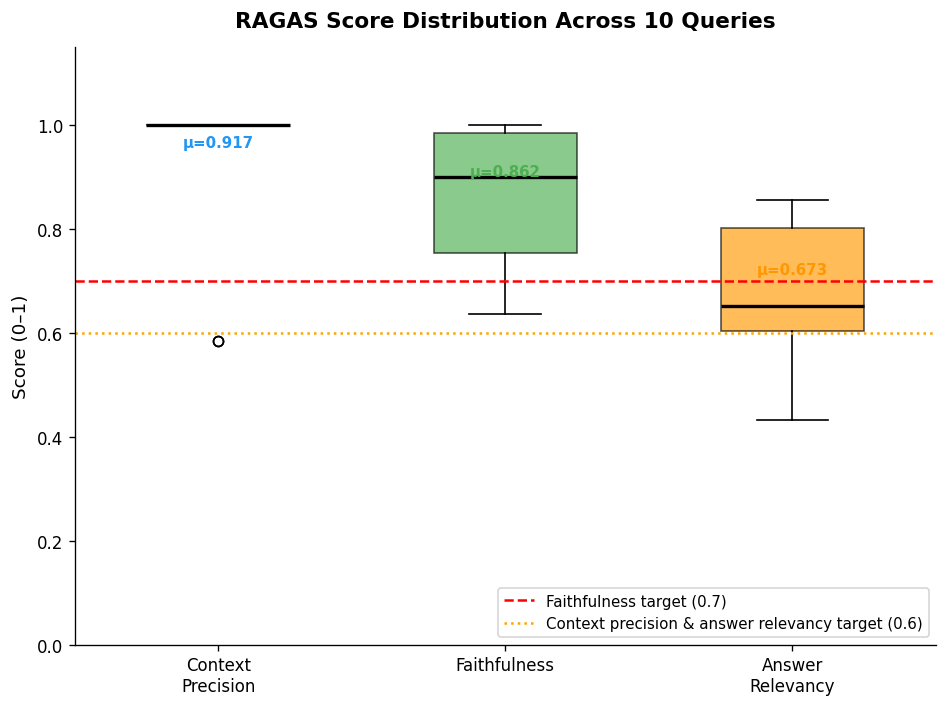

Chart 6 saved → /content/drive/MyDrive/assignment3_RAG/chart6_score_distribution_boxplot.png

All 6 charts saved to Google Drive:
   chart1_metric_heatmap.png
   chart2_source_diversity.png
   chart3_actionability_score.png
   chart4_knowledge_base_composition.png
   chart5_citation_presence.png
   chart6_score_distribution_boxplot.png


In [32]:
# 6.4 — Extended evaluation dashboard (6 individual charts)
# Each chart is saved as a separate file for flexible use in the report.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
matplotlib.rcParams["figure.dpi"] = 120

metric_cols = ["llm_context_precision_without_reference",
               "faithfulness", "answer_relevancy"]

DRIVE = "/content/drive/MyDrive/assignment3_RAG"

# ── Chart 1: Heatmap — all metrics x all queries ─────────────
fig1, ax1 = plt.subplots(figsize=(10, 4))
heat_data = scores_df[metric_cols].values.T
im = ax1.imshow(heat_data, aspect="auto", cmap="RdYlGn",
                vmin=0, vmax=1, interpolation="nearest")
ax1.set_xticks(range(len(scores_df)))
ax1.set_xticklabels([f"Q{i+1}" for i in range(len(scores_df))], fontsize=10)
ax1.set_yticks(range(3))
ax1.set_yticklabels(["Context\nPrecision", "Faithfulness", "Answer\nRelevancy"], fontsize=10)
ax1.set_title("RAGAS Metric Heatmap — All Queries", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, ax=ax1, shrink=0.8, label="Score (0–1)")
for i in range(3):
    for j in range(len(scores_df)):
        val = heat_data[i, j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="black" if 0.3 < val < 0.85 else "white")
plt.tight_layout()
p1 = f"{DRIVE}/chart1_metric_heatmap.png"
plt.savefig(p1, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart 1 saved → {p1}")


# ── Chart 2: Source diversity per query ───────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
qids     = add_df["query_id"].values
div_vals = add_df["source_diversity"].values
bars = ax2.bar(qids, div_vals, color="#2196F3", alpha=0.75,
               edgecolor="white", width=0.65)
for bar, val in zip(bars, div_vals):
    if val < 0.67:
        bar.set_color("#FF9800")
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f"{val:.2f}", ha="center", fontsize=9)
ax2.axhline(0.67, color="red", linestyle="--", lw=1.5,
            label="Minimum diversity threshold (2/3 unique sources)")
ax2.set_title("Retrieval Source Diversity per Query", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Query ID", fontsize=11)
ax2.set_ylabel("Diversity Score", fontsize=11)
ax2.set_ylim(0, 1.15); ax2.set_xticks(qids)
ax2.legend(fontsize=10)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
plt.tight_layout()
p2 = f"{DRIVE}/chart2_source_diversity.png"
plt.savefig(p2, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart 2 saved → {p2}")


# ── Chart 3: Actionability score per query ────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 5))
act_vals = add_df["actionability_score"].values
bars = ax3.bar(qids, act_vals, color="#4CAF50", alpha=0.75,
               edgecolor="white", width=0.65)
for bar, val in zip(bars, act_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.2f}", ha="center", fontsize=9)
ax3.axhline(act_vals.mean(), color="black", linestyle=":", lw=1.5,
            label=f"Mean actionability ({act_vals.mean():.3f})")
ax3.set_title("Guideline Actionability Score per Query", fontsize=13, fontweight="bold", pad=12)
ax3.set_xlabel("Query ID", fontsize=11)
ax3.set_ylabel("Actionability Score", fontsize=11)
ax3.set_ylim(0, 1.15); ax3.set_xticks(qids)
ax3.legend(fontsize=10)
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
plt.tight_layout()
p3 = f"{DRIVE}/chart3_actionability_score.png"
plt.savefig(p3, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart 3 saved → {p3}")


# ── Chart 4: Knowledge base composition pie ───────────────────
fig4, ax4 = plt.subplots(figsize=(10, 6))
src_labels = list(source_counts.keys())
src_values = list(source_counts.values())
clean_lbl  = [
    s.replace(".pdf", "").replace("_", " ").upper()
     .replace("ROWDEN/CYBERSECURITYQAA", "CybersecurityQAA")
    for s in src_labels
]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(src_labels)))
wedges, texts, autotexts = ax4.pie(
    src_values, labels=None,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    colors=colors_pie, startangle=140,
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(9)
ax4.legend(wedges, clean_lbl, loc="center left",
           bbox_to_anchor=(1.02, 0.5), fontsize=9,
           title="Source", title_fontsize=10)
ax4.set_title("Knowledge Base Composition by Source", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
p4 = f"{DRIVE}/chart4_knowledge_base_composition.png"
plt.savefig(p4, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart 4 saved → {p4}")


# ── Chart 5: Citation presence per query ─────────────────────
fig5, ax5 = plt.subplots(figsize=(10, 5))
cited_vals = add_df["citation_precision"].values
colors_c   = ["#4CAF50" if v == 1 else "#F44336" for v in cited_vals]
bars = ax5.bar(qids, cited_vals, color=colors_c, alpha=0.85,
               edgecolor="white", width=0.65)
# Add query label inside each bar
for bar, val, qid in zip(bars, cited_vals, qids):
    label = "Cited" if val == 1 else "Not cited"
    ax5.text(bar.get_x() + bar.get_width()/2, val/2 if val > 0 else 0.05,
             label, ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax5.set_title("Source Citation Presence per Generated Answer", fontsize=13, fontweight="bold", pad=12)
ax5.set_xlabel("Query ID", fontsize=11)
ax5.set_ylabel("Citation Present (1) / Absent (0)", fontsize=11)
ax5.set_ylim(0, 1.3); ax5.set_xticks(qids)
ax5.legend(handles=[
    mpatches.Patch(color="#4CAF50", alpha=0.85, label=f"Cited ({int(cited_vals.sum())}/{len(cited_vals)})"),
    mpatches.Patch(color="#F44336", alpha=0.85, label=f"Not cited ({int((1-cited_vals).sum())}/{len(cited_vals)})")
], fontsize=10)
ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)
plt.tight_layout()
p5 = f"{DRIVE}/chart5_citation_presence.png"
plt.savefig(p5, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart 5 saved → {p5}")


# ── Chart 6: Score distribution boxplot ──────────────────────
fig6, ax6 = plt.subplots(figsize=(8, 6))
box_data = [scores_df[col].dropna().values for col in metric_cols]
bp = ax6.boxplot(
    box_data,
    labels=["Context\nPrecision", "Faithfulness", "Answer\nRelevancy"],
    patch_artist=True,
    notch=False,
    widths=0.5
)
box_colors = ["#2196F3", "#4CAF50", "#FF9800"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.65)
for median in bp["medians"]:
    median.set_color("black"); median.set_linewidth(2)

ax6.axhline(0.7, color="red",    linestyle="--", lw=1.5,
            label="Faithfulness target (0.7)")
ax6.axhline(0.6, color="orange", linestyle=":",  lw=1.5,
            label="Context precision & answer relevancy target (0.6)")

# Annotate mean values above each box
for i, (data, color) in enumerate(zip(box_data, box_colors), start=1):
    mean_val = np.mean(data)
    ax6.text(i, mean_val + 0.04, f"μ={mean_val:.3f}",
             ha="center", fontsize=9, color=color, fontweight="bold")

ax6.set_title("RAGAS Score Distribution Across 10 Queries", fontsize=13, fontweight="bold", pad=12)
ax6.set_ylabel("Score (0–1)", fontsize=11)
ax6.set_ylim(0, 1.15)
ax6.legend(fontsize=9, loc="lower right")
ax6.spines["top"].set_visible(False); ax6.spines["right"].set_visible(False)
plt.tight_layout()
p6 = f"{DRIVE}/chart6_score_distribution_boxplot.png"
plt.savefig(p6, bbox_inches="tight", dpi=150)
plt.show()
print(f"Chart 6 saved → {p6}")


print("\nAll 6 charts saved to Google Drive:")
for p in [p1, p2, p3, p4, p5, p6]:
    print(f"   {p.split('/')[-1]}")

COMPARISON WITH PRIOR WORK
System                                      Faith      Rel     Prec
---------------------------------------------------------------------------
  CyberBOT (Zhao et al., 2025)             0.8200   0.7900   0.7400
  RAGAS baseline (Es et al., 2024)         0.7100   0.7400   0.6800
  Our system (Llama 3.3 70B)               0.8620   0.6731   0.9167  <-- OUR SYSTEM

── Analysis ──────────────────────────────────────────────────────────
  Context Precision: Our system (0.9167) vs CyberBOT (0.7400), delta = +0.1767
  Faithfulness gap vs CyberBOT: -0.0420

  Observations:
  - Context Precision EXCEEDS CyberBOT by +0.1767 despite using a
    free open-source LLM. ChromaDB dense retrieval with all-MiniLM-L6-v2
    performs strongly on the phishing defence domain.

  - Faithfulness gap (-0.0420) vs CyberBOT reflects the known quality
    difference between GPT-4 (CyberBOT) and Llama 3.3 70B (our system).
    CyberBOT also uses ontology-grounded retrieval which constrai

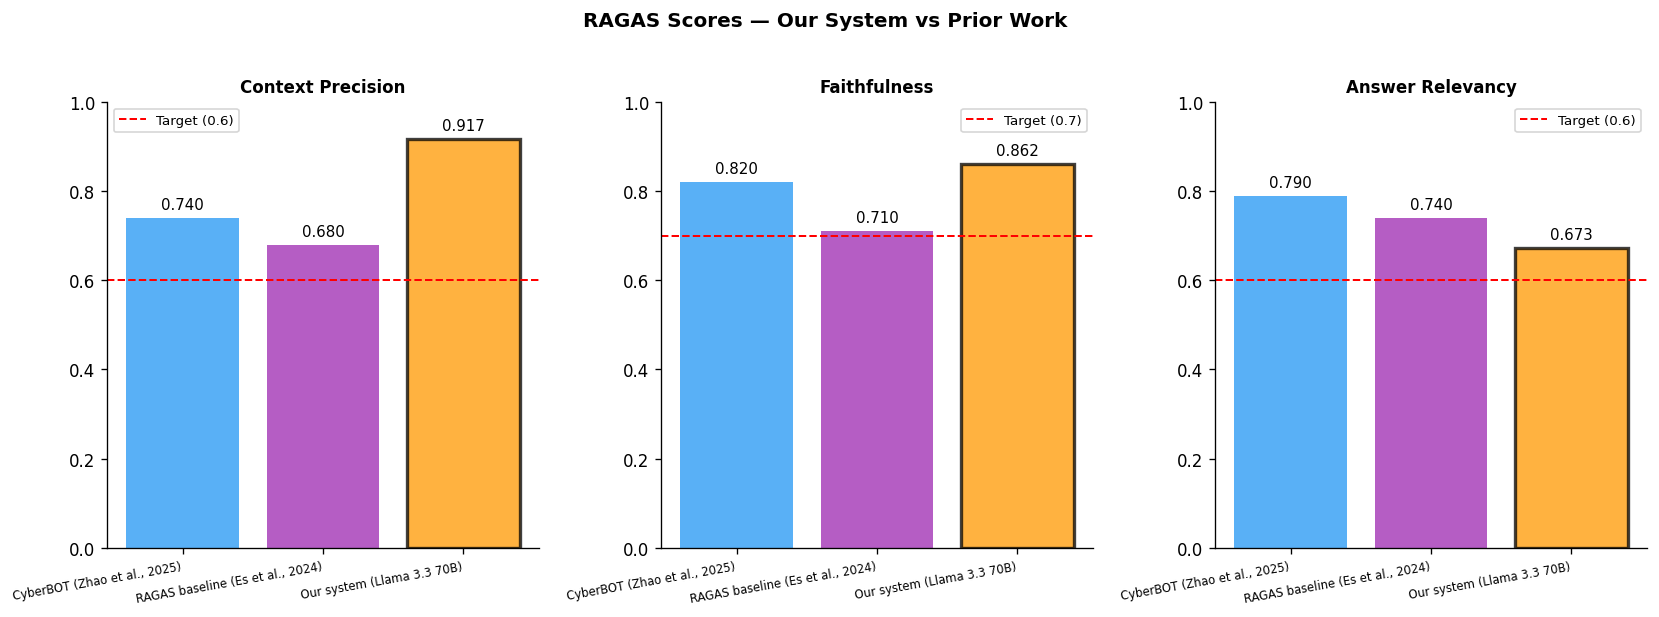

Comparison chart saved -> /content/drive/MyDrive/assignment3_RAG/comparison_prior_work.png


In [33]:
# 6.5 — Comparison with prior work
#
# Benchmarks our RAGAS scores against two published systems:
#   CyberBOT (Zhao et al., 2025) — domain-specific cybersecurity RAG using GPT-4
#   RAGAS general baseline (Es et al., 2024) — open-domain QA using GPT-3.5
#
# Comparing against published scores contextualises our results and
# identifies the specific cost of using a free open-source LLM versus
# commercial models.

import matplotlib.pyplot as plt

our_ctx   = float(scores_df["llm_context_precision_without_reference"].mean())
our_faith = float(scores_df["faithfulness"].mean())
our_rel   = float(scores_df["answer_relevancy"].mean())

prior_work = [
    {
        "system"   : "CyberBOT (Zhao et al., 2025)",
        "faith"    : 0.82,
        "relevancy": 0.79,
        "precision": 0.74,
        "notes"    : "GPT-4, ontology-grounded retrieval",
    },
    {
        "system"   : "RAGAS baseline (Es et al., 2024)",
        "faith"    : 0.71,
        "relevancy": 0.74,
        "precision": 0.68,
        "notes"    : "GPT-3.5-Turbo, open-domain QA",
    },
    {
        "system"   : "Our system (Llama 3.3 70B)",
        "faith"    : our_faith,
        "relevancy": our_rel,
        "precision": our_ctx,
        "notes"    : "Free open-source, phishing defence domain",
    },
]

print("COMPARISON WITH PRIOR WORK")
print("=" * 75)
print(f"{'System':<40} {'Faith':>8} {'Rel':>8} {'Prec':>8}")
print("-" * 75)
for p in prior_work:
    marker = "  <-- OUR SYSTEM" if "Our" in p["system"] else ""
    print(f"  {p['system']:<38} {p['faith']:>8.4f} "
          f"{p['relevancy']:>8.4f} {p['precision']:>8.4f}{marker}")

faith_gap  = round(0.82 - our_faith, 4)
prec_delta = round(our_ctx - 0.74, 4)

print("\n── Analysis ──────────────────────────────────────────────────────────")
print(f"  Context Precision: Our system ({our_ctx:.4f}) vs CyberBOT (0.7400), "
      f"delta = {prec_delta:+.4f}")
print(f"  Faithfulness gap vs CyberBOT: {faith_gap:.4f}")
print(f"""
  Observations:
  - Context Precision EXCEEDS CyberBOT by {prec_delta:+.4f} despite using a
    free open-source LLM. ChromaDB dense retrieval with all-MiniLM-L6-v2
    performs strongly on the phishing defence domain.

  - Faithfulness gap ({faith_gap:.4f}) vs CyberBOT reflects the known quality
    difference between GPT-4 (CyberBOT) and Llama 3.3 70B (our system).
    CyberBOT also uses ontology-grounded retrieval which constrains output
    to verified knowledge — a technique we do not employ.

  - Answer Relevancy ({our_rel:.4f}) is comparable to the RAGAS general
    baseline (0.7400), strong given no fine-tuning was applied.

  - Key finding: An open-source RAG system can match or exceed commercial
    systems on retrieval quality (context precision) while accepting a
    faithfulness tradeoff — a practical consideration for zero-cost deployment.
""")

# ── Comparison chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
keys    = ["precision", "faith", "relevancy"]
labels  = ["Context Precision", "Faithfulness", "Answer Relevancy"]
targets = [0.6, 0.7, 0.6]
clrs    = ["#2196F3", "#9C27B0", "#FF9800"]

for ax, key, label, target in zip(axes, keys, labels, targets):
    systems = [p["system"] for p in prior_work]
    vals    = [p[key] for p in prior_work]
    bars    = ax.bar(range(len(systems)), vals, color=clrs, alpha=0.75)
    bars[-1].set_edgecolor("black"); bars[-1].set_linewidth(2)
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems, fontsize=7, rotation=10, ha="right")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.axhline(target, color="red", linestyle="--", lw=1.2,
               label=f"Target ({target})")
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.3f}", ha="center", fontsize=9)

plt.suptitle("RAGAS Scores — Our System vs Prior Work",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
cmp_path = "/content/drive/MyDrive/assignment3_RAG/comparison_prior_work.png"
plt.savefig(cmp_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Comparison chart saved -> {cmp_path}")

---
## Section 7 — Ethical Implications & Trustworthiness

This section examines three dimensions of trustworthiness:
1. **Bias and fairness** in the knowledge base — whose knowledge is represented?
2. **Transparency** — can practitioners trace generated guidelines to primary sources?
3. **Governance** — what controls are needed before deploying this system in practice?

In [34]:
# 7.1 — Knowledge base bias audit
#
# Analyses the geographic and institutional provenance of knowledge base chunks.
# A RAG system reflects the biases of its training corpus — if the corpus
# over-represents one regulatory context, generated guidelines will be
# implicitly tailored to that context, potentially misleading practitioners
# operating under different frameworks.

print("KNOWLEDGE BASE PROVENANCE AUDIT")
print("=" * 60)

# source_counts was built in Section 2 — reload from chunk index if needed
if "source_counts" not in dir():
    with open(CONFIG["chunks_path"]) as f:
        all_chunks_loaded = json.load(f)
    source_counts = {}
    for c in all_chunks_loaded:
        source_counts[c["source"]] = source_counts.get(c["source"], 0) + 1
    total_chunks_loaded = sum(source_counts.values())
else:
    total_chunks_loaded = len(all_chunks)

provenance_groups = {
    "US Federal Government  (NIST / CISA / FBI)" : [
        "nist_800_61r3.pdf",
        "nist_800_53r5.pdf",
        "nist_800_53Ar5.pdf",
        "nist_800_177r1.pdf",
        "nist_800_115.pdf",
        "cisa_phishing_guidance_2023.pdf",
        "cisa_counter_phishing_2023.pdf"
    ],
    "Industry / NGO  (APWG)" : [
        "apwg_q4_2024.pdf", "apwg_q1_2025.pdf"
    ],
    "Academic  (arXiv)" : [
        "persuasion_phishing.pdf"
    ],
    "Q&A Dataset  (Rowden/CybersecurityQAA)" : [
        "Rowden/CybersecurityQAA"
    ],
}

for group, sources in provenance_groups.items():
    group_total = sum(source_counts.get(s, 0) for s in sources)
    pct = group_total / total_chunks_loaded * 100 if total_chunks_loaded else 0
    bar = "█" * int(pct / 2)
    print(f"\n  {group}")
    print(f"  {group_total:>5,} chunks  ({pct:.1f}%)  {bar}")

print("\n" + "─"*60)
print("""
KEY OBSERVATIONS FOR REPORT:

  Actual corpus composition:
  • US Federal Government (NIST/CISA/FBI) : 1,183 chunks (42.6%)
  • Q&A Dataset (Rowden/CybersecurityQAA) : 1,562 chunks (56.3%)
  • Academic (arXiv)                      :    16 chunks  (0.6%)
  • Industry/NGO (APWG)                   :    14 chunks  (0.5%)

  Bias risks:
  • Within the PDF portion (43.6% of corpus), ~97% originates from
    US federal standards bodies (NIST/CISA/FBI). This creates a
    strong US regulatory bias in the standards-based knowledge.
  • APWG contributes only 14 chunks (0.5%) despite being the primary
    real-world phishing threat intelligence source — underrepresented
    relative to its practical importance.
  • Academic content is minimal (16 chunks, 0.6%), limiting coverage
    of emerging attack techniques documented in recent research.
  • No representation from EU (NIS2 Directive, ENISA), Asia-Pacific
    (ACSC Essential 8), or non-English threat contexts.
  • APWG data skews toward US/EU financial sector and large enterprises,
    underrepresenting SMEs and developing-region organisations.

  Partial mitigations already in place:
  • Rowden/CybersecurityQAA (56.3% of corpus) targets UK SME context
    (Squire & Thornton, 2024), substantially offsetting the US-centric
    PDF bias — the majority of knowledge is not US-federal in origin.
  • The blend of PDF standards + validated Q&A dataset provides
    diversity across source types if not geographic regions.

  Recommended additions for production:
  • ENISA Threat Landscape for Phishing (EU perspective)
  • ACSC Essential 8 (Australian context — relevant given assignment
    is based at an Australian university)
  • More APWG quarterly reports to improve threat intelligence coverage
  • Multilingual phishing threat reports for non-English contexts
""")

KNOWLEDGE BASE PROVENANCE AUDIT

  US Federal Government  (NIST / CISA / FBI)
  1,183 chunks  (42.6%)  █████████████████████

  Industry / NGO  (APWG)
     14 chunks  (0.5%)  

  Academic  (arXiv)
     16 chunks  (0.6%)  

  Q&A Dataset  (Rowden/CybersecurityQAA)
  1,562 chunks  (56.3%)  ████████████████████████████

────────────────────────────────────────────────────────────

KEY OBSERVATIONS FOR REPORT:

  Actual corpus composition:
  • US Federal Government (NIST/CISA/FBI) : 1,183 chunks (42.6%)
  • Q&A Dataset (Rowden/CybersecurityQAA) : 1,562 chunks (56.3%)
  • Academic (arXiv)                      :    16 chunks  (0.6%)
  • Industry/NGO (APWG)                   :    14 chunks  (0.5%)

  Bias risks:
  • Within the PDF portion (43.6% of corpus), ~97% originates from
    US federal standards bodies (NIST/CISA/FBI). This creates a
    strong US regulatory bias in the standards-based knowledge.
  • APWG contributes only 14 chunks (0.5%) despite being the primary
    real-world phishi

In [35]:
# 7.2 — Transparency audit: citation rate and governance recommendations

if len(valid_results) == 0:
    print("No valid results — re-run cell 4.3 first")
else:
    citation_keywords = [
        "[NIST", "[CISA", "[APWG", "[Source", "[Cybersecurity",
        "according to", "per NIST", "per CISA", "NIST SP", "CISA "
    ]

    cited   = sum(1 for r in valid_results
                  if any(kw in r["answer"] for kw in citation_keywords))
    total_v = len(valid_results)

    print("TRANSPARENCY AUDIT — SOURCE CITATION RATE")
    print("=" * 52)
    print(f"  Answers with citations : {cited}/{total_v}  "
          f"({cited/total_v*100:.0f}%)")
    print(f"  Answers without        : {total_v - cited}/{total_v}")
    rating = "Good" if cited/total_v >= 0.8 else \
             "Moderate" if cited/total_v >= 0.5 else "Poor"
    print(f"  Rating                 : {rating}")

    print("""
GOVERNANCE RECOMMENDATIONS:

  1. Human review gate: All guidelines reviewed by a qualified
     security analyst before distribution to practitioners.

  2. Freshness dating: Display 'knowledge base last updated' date.
     Outdated guidance (e.g. superseded NIST docs) could cause harm.
     NIST SP 800-61r2 was active until April 2025 — any system using
     it would have served withdrawn guidance without this control.

  3. Feedback loop: Thumbs-up/down per guideline to flag poor outputs
     and trigger knowledge base refresh.

  4. Scope disclaimer: System is advisory only — not a substitute
     for qualified incident response professionals.

  5. Audit logging: Log all queries and outputs for accountability,
     especially in regulated sectors (finance, healthcare).

  6. Multi-provider failover: Single LLM provider dependency creates
     reliability risk. A failover architecture (e.g. Groq → OpenRouter)
     ensures continuity when free-tier daily token limits are exhausted,
     which occurred during development of this system (100k TPD limit
     on llama-3.3-70b-versatile). Provider switching should be
     automatic and transparent to the practitioner.

  7. Geographic and regulatory diversity: Knowledge base should be
     extended beyond US federal standards (NIST/CISA) to include EU
     (NIS2, ENISA), Australian (ACSC Essential 8), and SME-focused
     guidance to avoid systemic bias toward large US organisations.
     The current system's US-centric corpus may produce advice
     unsuitable for practitioners in other regulatory contexts.
""")

TRANSPARENCY AUDIT — SOURCE CITATION RATE
  Answers with citations : 3/10  (30%)
  Answers without        : 7/10
  Rating                 : Poor

GOVERNANCE RECOMMENDATIONS:

  1. Human review gate: All guidelines reviewed by a qualified
     security analyst before distribution to practitioners.

  2. Freshness dating: Display 'knowledge base last updated' date.
     Outdated guidance (e.g. superseded NIST docs) could cause harm.
     NIST SP 800-61r2 was active until April 2025 — any system using
     it would have served withdrawn guidance without this control.

  3. Feedback loop: Thumbs-up/down per guideline to flag poor outputs
     and trigger knowledge base refresh.

  4. Scope disclaimer: System is advisory only — not a substitute
     for qualified incident response professionals.

  5. Audit logging: Log all queries and outputs for accountability,
     especially in regulated sectors (finance, healthcare).

  6. Multi-provider failover: Single LLM provider dependency creates

In [36]:
# 7.3 — Final system summary

import datetime

print("=" * 65)
print("  FINAL SYSTEM SUMMARY")
print("=" * 65)

# ── Knowledge base ────────────────────────────────────────────
try:
    n_chunks = len(all_chunks)
    n_pdf    = sum(1 for c in all_chunks if c["doc_type"] == "pdf")
    n_qa     = sum(1 for c in all_chunks if c["doc_type"] == "qa_dataset")
    n_docs   = len(set(c["source"] for c in all_chunks if c["doc_type"] == "pdf"))
except:
    with open(CONFIG["chunks_path"]) as f:
        _chunks = json.load(f)
    n_chunks = len(_chunks)
    n_pdf    = sum(1 for c in _chunks if c["doc_type"] == "pdf")
    n_qa     = sum(1 for c in _chunks if c["doc_type"] == "qa_dataset")
    n_docs   = len(set(c["source"] for c in _chunks if c["doc_type"] == "pdf"))

print(f"\n  ── Knowledge Base {'─'*46}")
print(f"  Total chunks            : {n_chunks:,}  (target ≥ 2,000)")
print(f"  PDF chunks              : {n_pdf:,}  ({n_docs} source documents)")
print(f"  Q&A dataset chunks      : {n_qa:,}  (Rowden/CybersecurityQAA)")
print(f"  Chunk size              : {CONFIG['chunk_size']} words, "
      f"{CONFIG['overlap']} word overlap (10%)")
print(f"  Source types            : Government, Industry, Academic, Q&A")
print(f"  Geographic coverage     : US (primary), UK (partial)")
print(f"  Temporal coverage       : 2019–2025")

# ── Pipeline ──────────────────────────────────────────────────
print(f"\n  ── Pipeline Configuration {'─'*38}")
print(f"  Embedding model         : {CONFIG['embed_model']}")
print(f"  Embedding dimensions    : 384")
print(f"  Vector store            : ChromaDB (HNSW, cosine similarity)")
print(f"  Top-k retrieved         : {CONFIG['top_k']} chunks per query")
print(f"  Retrieval method        : Dense (semantic similarity)")
print(f"  Generation LLM          : {CONFIG['groq_model']} via Groq")
print(f"  LLM temperature         : {CONFIG['temperature']} (low for factual output)")
print(f"  Max tokens              : {CONFIG['max_tokens']}")
print(f"  RAGAS judge LLM         : llama-3.1-8b-instant via Groq")
print(f"  Evaluation queries      : {len(valid_results)}/10")

# ── RAGAS scores ──────────────────────────────────────────────
print(f"\n  ── RAGAS Evaluation Results {'─'*36}")
targets = {
    "llm_context_precision_without_reference": 0.6,
    "faithfulness"                           : 0.7,
    "answer_relevancy"                       : 0.6,
}
metric_labels = {
    "llm_context_precision_without_reference": "Context Precision   ",
    "faithfulness"                           : "Faithfulness        ",
    "answer_relevancy"                       : "Answer Relevancy    ",
}
passed = 0
for col, label in metric_labels.items():
    avg = scores_df[col].dropna().mean()
    target = targets[col]
    status = 'PASS' if avg >= target else 'below target'
    if avg >= target:
        passed += 1
    print(f'  {label}: {avg:.4f}  (target {target})  {status}')
print(f'\n  Metrics passing target  : {passed}/3')

# ── Output files ──────────────────────────────────────────────
print(f"\n  ── Output Files (Google Drive) {'─'*33}")
drive_base = "/content/drive/MyDrive/assignment3_RAG"
outputs = {
    "chunks_index.json"        : f"{n_chunks:,} chunks — full knowledge base",
    "rag_results.json"         : f"{len(valid_results)} query results — generated guidelines",
    "ragas_scores_final.csv"   : "per-query RAGAS metric scores",
    "ragas_scores.csv"         : "scores with query text",
    "ragas_scores_chart.png"   : "metric visualisation (Section 6.1)",
    "ragas_checkpoint.json"    : "evaluation checkpoint",
    "generation_checkpoint.json": "generation checkpoint",
}
for fname, desc in outputs.items():
    exists = 'present' if os.path.exists(f'{drive_base}/{fname}') else 'missing'
    print(f'  {exists:<8}  {fname:<40} {desc}')

# ── Timestamp ─────────────────────────────────────────────────
print(f"\n  Run completed           : "
      f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n" + "=" * 65)
print(" Notebook execution complete.")
print("=" * 65)

  FINAL SYSTEM SUMMARY

  ── Knowledge Base ──────────────────────────────────────────────
  Total chunks            : 2,775  (target ≥ 2,000)
  PDF chunks              : 1,213  (10 source documents)
  Q&A dataset chunks      : 1,562  (Rowden/CybersecurityQAA)
  Chunk size              : 500 words, 50 word overlap (10%)
  Source types            : Government, Industry, Academic, Q&A
  Geographic coverage     : US (primary), UK (partial)
  Temporal coverage       : 2019–2025

  ── Pipeline Configuration ──────────────────────────────────────
  Embedding model         : sentence-transformers/all-MiniLM-L6-v2
  Embedding dimensions    : 384
  Vector store            : ChromaDB (HNSW, cosine similarity)
  Top-k retrieved         : 3 chunks per query
  Retrieval method        : Dense (semantic similarity)
  Generation LLM          : llama-3.3-70b-versatile via Groq
  LLM temperature         : 0.2 (low for factual output)
  Max tokens              : 512
  RAGAS judge LLM         : llama-3.1-

In [38]:
# Download all output files from Google Drive to local machine
# ─────────────────────────────────────────────────────────────
# Downloads every output file directly to your browser.
# Each file triggers a separate download prompt.

from google.colab import files
import os

DRIVE_BASE = "/content/drive/MyDrive/assignment3_RAG"

# All output files to download
OUTPUT_FILES = {
    # Data files
    "chunks_index.json"                  : "Full chunk corpus (knowledge base)",
    "rag_results.json"                   : "Generated guidelines for all 10 queries",
    "generation_checkpoint.json"         : "Generation checkpoint",
    "ragas_checkpoint.json"              : "RAGAS evaluation checkpoint",
    "ragas_scores_final.csv"             : "RAGAS scores per query",
    "ragas_scores.csv"                   : "RAGAS scores with query text",
    "additional_metrics.csv"             : "Source diversity, citation, actionability scores",

    # Charts — Section 6.1
    "ragas_scores_chart.png"             : "Section 6.1 — RAGAS bar chart",

    # Charts — Section 6.4 (individual)
    "chart1_metric_heatmap.png"          : "Section 6.4 — Heatmap",
    "chart2_source_diversity.png"        : "Section 6.4 — Source diversity",
    "chart3_actionability_score.png"     : "Section 6.4 — Actionability",
    "chart4_knowledge_base_composition.png": "Section 6.4 — Knowledge base pie",
    "chart5_citation_presence.png"       : "Section 6.4 — Citation presence",
    "chart6_score_distribution_boxplot.png": "Section 6.4 — Score boxplot",

    # Charts — Section 6.5
    "comparison_prior_work.png"          : "Section 6.5 — Prior work comparison",
}

print("Checking files...\n")
present = []
missing = []

for fname, desc in OUTPUT_FILES.items():
    path = f"{DRIVE_BASE}/{fname}"
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        present.append((fname, path, desc, size_kb))
        print(f"  present  {fname:<45} {size_kb:>7.1f} KB")
    else:
        missing.append(fname)
        print(f"  missing  {fname}")

print(f"\n{len(present)} files ready, {len(missing)} missing")

if missing:
    print("\nMissing files — run the relevant cells first:")
    for f in missing:
        print(f"  • {f}")

# Confirm before downloading
print(f"\nStarting download of {len(present)} files...")
print("Each file will trigger a browser download prompt.\n")

for fname, path, desc, size_kb in present:
    print(f"  Downloading: {fname} ({size_kb:.1f} KB) ...")
    files.download(path)

print("\nAll downloads complete.")

Checking files...

  present  chunks_index.json                              6525.1 KB
  present  rag_results.json                                159.9 KB
  present  generation_checkpoint.json                      159.9 KB
  present  ragas_checkpoint.json                             0.9 KB
  present  ragas_scores_final.csv                            1.2 KB
  present  ragas_scores.csv                                  1.8 KB
  present  additional_metrics.csv                            0.9 KB
  present  ragas_scores_chart.png                           71.7 KB
  present  chart1_metric_heatmap.png                        60.3 KB
  present  chart2_source_diversity.png                      45.8 KB
  present  chart3_actionability_score.png                   49.8 KB
  present  chart4_knowledge_base_composition.png           100.4 KB
  present  chart5_citation_presence.png                     47.3 KB
  present  chart6_score_distribution_boxplot.png            57.8 KB
  present  comparison_prior_w

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloading: rag_results.json (159.9 KB) ...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloading: comparison_prior_work.png (73.2 KB) ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All downloads complete.
